In [19]:
import requests
import folium

# ==========================================
# 1. DATASET FINAL (Koordinat Akurat ITS)
# ==========================================
locations = {
    "Gerbang Depan (Bunderan)": (-7.279558, 112.790744),
    "Sistem Informasi ITS": (-7.280261130418485, 112.79675537634462),
    "TW1": (-7.285122599662305, 112.79351321918422),
    "Gerbang Keputih": (-7.2903264145324, 112.79207920957046),
    "Gerbang Mulyosari": (-7.277259, 112.796340),
    "Infinits Park": (-7.286060, 112.795803),
    "Manarul": (-7.282330, 112.792496),
    "FTK": (-7.282185243866885, 112.79851318524543),
    "Gedung Rektorat": (-7.28142122887683, 112.79428991746977),
    "J-one (Warkamm)": (-7.287406666592738, 112.79457818308369)
}

# ==========================================
# 2. BIKIN PETA DASAR & MARKER
# ==========================================
m = folium.Map(location=[-7.283, 112.793], zoom_start=15)

for i, (name, coords) in enumerate(locations.items()):
    folium.Marker(
        location=coords,
        popup=f"Titik {i+1}: {name}",
        tooltip=name,
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m)

# ==========================================
# 3. TARIK DATA GARIS JALAN (OSRM ROUTE API)
# ==========================================
print("Sedang menarik data geometri jalan dari satelit OSRM...")

# Siapkan string koordinat: lon1,lat1;lon2,lat2;...
coords_list = [f"{lon},{lat}" for lat, lon in locations.values()]

# Kita bikin rute loop: 1 -> 2 -> 3 ... -> 10 -> balik ke 1 lagi
route_coords_str = ";".join(coords_list) + f";{coords_list[0]}"

# Panggil API OSRM Route (minta output geometries=geojson biar gampang digambar)
url_route = f"http://router.project-osrm.org/route/v1/driving/{route_coords_str}?overview=full&geometries=geojson"

try:
    response = requests.get(url_route).json()
    
    if response.get("code") == "Ok":
        # Ambil data jejak jalan (berupa list panjang koordinat aspal)
        route_geometry = response["routes"][0]["geometry"]["coordinates"]
        
        # OSRM ngasih format [lon, lat], Folium butuhnya [lat, lon], jadi kita balik dulu
        folium_route = [(lat, lon) for lon, lat in route_geometry]
        
        # Gambar garisnya di atas peta
        folium.PolyLine(
            folium_route,
            color="blue",
            weight=5,
            opacity=0.7,
            tooltip="Rute Lari/Sepeda (Real Road)"
        ).add_to(m)
        
        print("Berhasil menggambar garis jalan raya di peta!")
    else:
        print("Gagal ambil rute dari OSRM:", response)
        
except Exception as e:
    print("Error saat menghubungi OSRM:", e)

# ==========================================
# 4. SIMPAN PETA
# ==========================================
m.save("peta_garis_real_its.html")
print("[SUKSES] Buka file 'peta_garis_real_its.html' di browsermu.")

Sedang menarik data geometri jalan dari satelit OSRM...
Berhasil menggambar garis jalan raya di peta!
[SUKSES] Buka file 'peta_garis_real_its.html' di browsermu.


# Nearest Neighbor Algorithm - Surabaya Tour Optimization

In [20]:
import requests
import folium
from folium.plugins import AntPath
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DATASET SURABAYA (25 LOKASI)
# ==========================================
locations = {
    "1. Monumen Kapal Selam": (-7.2654, 112.7503),
    "2. Tugu Pahlawan": (-7.2453, 112.7379),
    "3. Jembatan Merah": (-7.2365, 112.7383),
    "4. Hotel Majapahit": (-7.2573, 112.7388),
    "5. Balai Kota Surabaya": (-7.2589, 112.7469),
    "6. House of Sampoerna": (-7.2306, 112.7343),
    "7. Museum Surabaya (Siola)": (-7.2514, 112.7363),
    "8. Rumah WR Soepratman": (-7.2504, 112.7538),
    "9. Gedung De Javasche Bank": (-7.2365, 112.7358),
    "10. Gereja Katolik Kepanjen": (-7.2435, 112.7335),
    "11. Jembatan Petekan": (-7.222192, 112.738044),
    "12. Gedung Internatio": (-7.236281, 112.736915),
    "13. Gedung Negara Grahadi": (-7.263524, 112.743179),
    "14. Kantor Pos Kebon Rojo": (-7.243218, 112.737700),
    "15. Rumah HOS Tjokroaminoto": (-7.252464, 112.737747),
    "16. Makam Belanda Peneleh": (-7.253019586881285, 112.74035309946457),
    "17. Kampung Lawang Seketeng": (-7.250495592744265, 112.74075173450092),
    "18. Gerbang Depan ITS": (-7.279395032652996, 112.79009468032517),
    "19. Gedung Cerutu": (-7.2360970729302325, 112.73704713519352),
    "20. Patung Karapan Sapi": (-7.272209191963128, 112.74209506903166),
    "21. Klenteng Sanggar Agung": (-7.247199578801502, 112.80219558900477),
    "22. Museum Pendidikan": (-7.255254406638845, 112.74278515368215),
    "23. Klenteng Hong Tiek Hian": (-7.2367971558297395, 112.74387553040685),
    "24. Monumen Bambu Runcing": (-7.267096754354455, 112.74418425368475),
    "25. Taman Prestasi": (-7.261174085645066, 112.74291416110384)
}

names = list(locations.keys())
n_points = len(names)
depo_index = names.index("18. Gerbang Depan ITS")

print(f"Total lokasi: {n_points}")
print(f"Depot (START & END): {names[depo_index]}")

# ==========================================
# 2. DATA ELEVASI (OPEN-ELEVATION API)
# ==========================================
print("\nMenarik data elevasi real dari Open-Elevation API...")
payload = {"locations": [{"latitude": lat, "longitude": lon} for lat, lon in locations.values()]}
try:
    elev_res = requests.post("https://api.open-elevation.com/api/v1/lookup", json=payload).json()
    elevation_data = {names[i]: elev_res['results'][i]['elevation'] for i in range(n_points)}
    print(f"✓ Elevasi berhasil diambil ({n_points} lokasi)")
except Exception as e:
    print(f"✗ Gagal ambil elevasi: {e}")
    elevation_data = {name: 0 for name in names}

# ==========================================
# 3. MATRIKS JARAK REAL (OSRM API)
# ==========================================
print("\nMenarik matriks jarak jalan raya dari OSRM...")
coords_string = ";".join([f"{lon},{lat}" for lat, lon in locations.values()])
try:
    url_table = f"http://router.project-osrm.org/table/v1/driving/{coords_string}?annotations=distance"
    distance_matrix = requests.get(url_table).json()["distances"]
    print(f"✓ Matriks jarak berhasil diambil ({n_points}x{n_points})")
except Exception as e:
    print(f"✗ Gagal ambil matriks jarak: {e}")
    # Fallback: hitung jarak euclidean
    distance_matrix = []
    for i in range(n_points):
        row = []
        for j in range(n_points):
            lat1, lon1 = locations[names[i]]
            lat2, lon2 = locations[names[j]]
            dist = np.sqrt((lat2-lat1)**2 + (lon2-lon1)**2) * 111000  # km to meter
            row.append(dist)
        distance_matrix.append(row)

# ==========================================
# 4. FUNGSI COST (JARAK + ELEVASI)
# ==========================================
def calculate_total_cost(route):
    """
    Menghitung total cost berdasarkan:
    - Jarak sebenarnya dari OSRM
    - Penalti elevasi 50m untuk tiap 1m tanjakan
    """
    total_cost = 0
    curr = depo_index
    
    for node in route:
        dist = distance_matrix[curr][node]
        diff = elevation_data[names[node]] - elevation_data[names[curr]]
        # Penalti 50m untuk tiap 1m tanjakan (downhill tidak ada penalti)
        penalty = (diff * 50) if diff > 0 else 0
        total_cost += (dist + penalty)
        curr = node
    
    # Kembali ke depo
    dist_back = distance_matrix[curr][depo_index]
    diff_back = elevation_data[names[depo_index]] - elevation_data[names[curr]]
    penalty_back = (diff_back * 50) if diff_back > 0 else 0
    total_cost += dist_back + penalty_back
    
    return total_cost

# ==========================================
# 5. NEAREST NEIGHBOR ALGORITHM
# ==========================================
print("\n" + "="*50)
print("NEAREST NEIGHBOR ALGORITHM")
print("="*50)

other_points = [i for i in range(n_points) if i != depo_index]
current_node = depo_index
visited = [current_node]
unvisited = set(other_points)

print(f"Mulai dari: {names[depo_index]}")
print(f"Iterasi pemilihan lokasi terdekat:\n")

iteration = 1
while unvisited:
    # Cari lokasi terdekat yang belum dikunjungi
    nearest_node = None
    nearest_cost = float('inf')
    
    for candidate in unvisited:
        dist = distance_matrix[current_node][candidate]
        elev_diff = elevation_data[names[candidate]] - elevation_data[names[current_node]]
        penalty = (elev_diff * 50) if elev_diff > 0 else 0
        total_cost_to_candidate = dist + penalty
        
        if total_cost_to_candidate < nearest_cost:
            nearest_cost = total_cost_to_candidate
            nearest_node = candidate
    
    visited.append(nearest_node)
    unvisited.remove(nearest_node)
    
    print(f"[Iter {iteration}] Dari: {names[current_node][:20]:20s} -> "
          f"Ke: {names[nearest_node][:20]:20s} | Cost: {nearest_cost:8.1f}m")
    
    current_node = nearest_node
    iteration += 1

# Rute final (tanpa depot di awal, akan ditambah saat visualisasi)
best_route = [v for v in visited if v != depo_index]
best_cost = calculate_total_cost(best_route)

print(f"\n{'='*50}")
print(f"HASIL NEAREST NEIGHBOR")
print(f"{'='*50}")
print(f"Total Cost (Jarak Efektif): {best_cost:.2f} meter")
print(f"Total Cost (Jarak Efektif): {best_cost/1000:.2f} km")

# Info rute
total_elev_gain = sum([
    max(0, elevation_data[names[best_route[i]]] - elevation_data[names[best_route[i-1]]])
    for i in range(len(best_route))
]) + max(0, elevation_data[names[depo_index]] - elevation_data[names[best_route[-1]]])

print(f"Total Elevation Gain: {total_elev_gain:.1f} meter")
print(f"Jumlah Lokasi: {len(best_route)}")


Total lokasi: 25
Depot (START & END): 18. Gerbang Depan ITS

Menarik data elevasi real dari Open-Elevation API...
✓ Elevasi berhasil diambil (25 lokasi)

Menarik matriks jarak jalan raya dari OSRM...
✓ Matriks jarak berhasil diambil (25x25)

NEAREST NEIGHBOR ALGORITHM
Mulai dari: 18. Gerbang Depan ITS
Iterasi pemilihan lokasi terdekat:

[Iter 1] Dari: 18. Gerbang Depan IT -> Ke: 21. Klenteng Sanggar | Cost:   5256.4m
[Iter 2] Dari: 21. Klenteng Sanggar -> Ke: 8. Rumah WR Soepratm | Cost:   8434.7m
[Iter 3] Dari: 8. Rumah WR Soepratm -> Ke: 5. Balai Kota Suraba | Cost:   1925.3m
[Iter 4] Dari: 5. Balai Kota Suraba -> Ke: 25. Taman Prestasi   | Cost:    830.1m
[Iter 5] Dari: 25. Taman Prestasi   -> Ke: 22. Museum Pendidika | Cost:    836.1m
[Iter 6] Dari: 22. Museum Pendidika -> Ke: 16. Makam Belanda Pe | Cost:    899.9m
[Iter 7] Dari: 16. Makam Belanda Pe -> Ke: 15. Rumah HOS Tjokro | Cost:    702.0m
[Iter 8] Dari: 15. Rumah HOS Tjokro -> Ke: 7. Museum Surabaya ( | Cost:   1364.2m
[Iter

In [21]:
# ==========================================
# 6. VISUALISASI PETA (ANT PATH + ELEVATION)
# ==========================================
print("\n" + "="*50)
print("VISUALISASI PETA RUTE")
print("="*50 + "\n")

final_indices = [depo_index] + best_route + [depo_index]
m = folium.Map(location=[-7.26, 112.75], zoom_start=13, tiles="cartodbpositron")

print("Menyusun peta rute nyata dari OSRM...")
route_segments = []

for i in range(len(final_indices) - 1):
    u_idx, v_idx = final_indices[i], final_indices[i+1]
    u_loc, v_loc = locations[names[u_idx]], locations[names[v_idx]]
    
    try:
        res = requests.get(
            f"http://router.project-osrm.org/route/v1/driving/{u_loc[1]},{u_loc[0]};{v_loc[1]},{v_loc[0]}?overview=full&geometries=geojson"
        ).json()
        
        if res.get("code") == "Ok":
            line = [[lat, lon] for lon, lat in res["routes"][0]["geometry"]["coordinates"]]
            
            # Tentukan warna berdasarkan elevasi
            is_uphill = elevation_data[names[v_idx]] > elevation_data[names[u_idx]]
            color = 'red' if is_uphill else 'blue'
            weight = 5 if is_uphill else 3
            
            # Gambar segment rute
            AntPath(
                locations=line,
                color=color,
                weight=weight,
                delay=1200,
                popup=f"{names[u_idx]} → {names[v_idx]}"
            ).add_to(m)
            
            dist_seg = distance_matrix[u_idx][v_idx]
            elev_u = elevation_data[names[u_idx]]
            elev_v = elevation_data[names[v_idx]]
            route_segments.append({
                'from': names[u_idx],
                'to': names[v_idx],
                'distance': dist_seg,
                'elev_from': elev_u,
                'elev_to': elev_v,
                'uphill': is_uphill
            })
    except Exception as e:
        print(f"  ✗ Error segment {u_idx}→{v_idx}: {e}")

# Tambah markers untuk setiap lokasi
for i, idx in enumerate(final_indices[:-1]):
    pos_order = "START/END" if idx == depo_index else f"#{i}"
    color = 'green' if idx == depo_index else 'cadetblue'
    icon = 'home' if idx == depo_index else 'map-pin'
    
    folium.Marker(
        location=locations[names[idx]],
        popup=f"<b>{pos_order}: {names[idx]}</b><br>Elevasi: {elevation_data[names[idx]]:.1f}m",
        tooltip=names[idx],
        icon=folium.Icon(color=color, icon=icon, prefix='fa')
    ).add_to(m)

m.save("rute_nearest_neighbor_surabaya.html")
print(f"✓ Peta tersimpan: 'rute_nearest_neighbor_surabaya.html'\n")

# ==========================================
# 7. RINGKASAN SEGMENT RUTE
# ==========================================
print("="*50)
print("DETAIL SEGMENT RUTE")
print("="*50)
print(f"{'#':<3} {'Dari':<25} {'Ke':<25} {'Jarak(m)':<10} {'Elev(m)':<10} {'Type':<8}")
print("-" * 100)

for i, seg in enumerate(route_segments, 1):
    elev_change = seg['elev_to'] - seg['elev_from']
    elev_type = "NAIK" if seg['uphill'] else "TURUN" if elev_change < 0 else "RATA"
    print(f"{i:<3} {seg['from'][:24]:<25} {seg['to'][:24]:<25} {seg['distance']:<10.0f} {elev_change:<10.1f} {elev_type:<8}")

print("="*50)
print(f"\nKeterangan warna peta:")
print("  🔴 MERAH  = Segment naik (uphill)")
print("  🔵 BIRU   = Segment turun/datar (downhill/flat)")
print("  🟢 HIJAU  = Depot (Gerbang Depan ITS)")
print(f"\n[SUKSES] Buka file 'rute_nearest_neighbor_surabaya.html' di browser untuk melihat peta interaktif.")



VISUALISASI PETA RUTE

Menyusun peta rute nyata dari OSRM...
✓ Peta tersimpan: 'rute_nearest_neighbor_surabaya.html'

DETAIL SEGMENT RUTE
#   Dari                      Ke                        Jarak(m)   Elev(m)    Type    
----------------------------------------------------------------------------------------------------
1   18. Gerbang Depan ITS     21. Klenteng Sanggar Agu  5256       -3.0       TURUN   
2   21. Klenteng Sanggar Agu  8. Rumah WR Soepratman    8185       5.0        NAIK    
3   8. Rumah WR Soepratman    5. Balai Kota Surabaya    1875       1.0        NAIK    
4   5. Balai Kota Surabaya    25. Taman Prestasi        830        -1.0       TURUN   
5   25. Taman Prestasi        22. Museum Pendidikan     786        1.0        NAIK    
6   22. Museum Pendidikan     16. Makam Belanda Penele  900        -1.0       TURUN   
7   16. Makam Belanda Penele  15. Rumah HOS Tjokroamin  602        2.0        NAIK    
8   15. Rumah HOS Tjokroamin  7. Museum Surabaya (Siol  1364    

In [22]:
# ==========================================
# 8. ANALISIS & VALIDASI CONSTRAINT
# ==========================================
print("\n" + "="*50)
print("VALIDASI CONSTRAINT & ANALISIS")
print("="*50 + "\n")

# Validasi 1: Semua lokasi dikunjungi
visited_set = set(best_route + [depo_index])
all_points_set = set(range(n_points))
constraint_1 = visited_set == all_points_set

print(f"✓ Constraint 1 - Semua lokasi dikunjungi:")
print(f"  Lokasi dalam rute: {len(visited_set)}/{n_points}")
print(f"  Status: {'VALID ✓' if constraint_1 else 'INVALID ✗'}\n")

# Validasi 2: Tidak ada lokasi yang dikunjungi 2x (kecuali depot)
route_visits = final_indices[:-1]  # Exclude last depot
duplicate_visits = len(route_visits) != len(set(route_visits))

print(f"✓ Constraint 2 - No revisit (kecuali depot):")
print(f"  Total visit: {len(route_visits)}")
print(f"  Unique visit: {len(set(route_visits))}")
print(f"  Status: {'VALID ✓' if not duplicate_visits else 'INVALID ✗'}\n")

# Validasi 3: Rute mulai dan berakhir di depot
starts_at_depot = final_indices[0] == depo_index
ends_at_depot = final_indices[-1] == depo_index

print(f"✓ Constraint 3 - Start & End di depot (Gerbang ITS):")
print(f"  Start index: {final_indices[0]} (expected {depo_index})")
print(f"  End index: {final_indices[-1]} (expected {depo_index})")
print(f"  Status: {'VALID ✓' if (starts_at_depot and ends_at_depot) else 'INVALID ✗'}\n")

# Statistik rute
total_distance = sum([seg['distance'] for seg in route_segments])
uphill_distance = sum([seg['distance'] for seg in route_segments if seg['uphill']])
downhill_distance = sum([seg['distance'] for seg in route_segments if not seg['uphill']])

print(f"{'─'*50}")
print(f"STATISTIK RUTE NEAREST NEIGHBOR")
print(f"{'─'*50}")
print(f"Total Jarak Nyata:           {total_distance:>15.0f} m ({total_distance/1000:.2f} km)")
print(f"  └─ Jarak Naik:            {uphill_distance:>15.0f} m")
print(f"  └─ Jarak Turun/Datar:     {downhill_distance:>15.0f} m")
print(f"Total Elevation Gain:        {total_elev_gain:>15.1f} m")
print(f"Total Cost (+ penalty):      {best_cost:>15.2f} m")
print(f"{'─'*50}\n")

# Informasi algoritma
print(f"INFORMASI ALGORITMA")
print(f"{'─'*50}")
print(f"Tipe Algoritma:              Nearest Neighbor (Greedy)")
print(f"Kompleksitas Waktu:          O(n²)")
print(f"Kompleksitas Ruang:          O(n)")
print(f"Sifat:                       Deterministik (1 solusi)")
print(f"Starting Point:              {names[depo_index]}")
print(f"{'─'*50}\n")

print("RINGKASAN VALIDASI:")
all_valid = constraint_1 and not duplicate_visits and starts_at_depot and ends_at_depot
print(f"Status Keseluruhan Constraint: {'✓ SEMUA VALID' if all_valid else '✗ ADA YANG TIDAK VALID'}")



VALIDASI CONSTRAINT & ANALISIS

✓ Constraint 1 - Semua lokasi dikunjungi:
  Lokasi dalam rute: 25/25
  Status: VALID ✓

✓ Constraint 2 - No revisit (kecuali depot):
  Total visit: 25
  Unique visit: 25
  Status: VALID ✓

✓ Constraint 3 - Start & End di depot (Gerbang ITS):
  Start index: 17 (expected 17)
  End index: 17 (expected 17)
  Status: VALID ✓

──────────────────────────────────────────────────
STATISTIK RUTE NEAREST NEIGHBOR
──────────────────────────────────────────────────
Total Jarak Nyata:                     61385 m (61.38 km)
  └─ Jarak Naik:                      22765 m
  └─ Jarak Turun/Datar:               38620 m
Total Elevation Gain:                   40.0 m
Total Cost (+ penalty):             63384.60 m
──────────────────────────────────────────────────

INFORMASI ALGORITMA
──────────────────────────────────────────────────
Tipe Algoritma:              Nearest Neighbor (Greedy)
Kompleksitas Waktu:          O(n²)
Kompleksitas Ruang:          O(n)
Sifat:             

In [38]:
# Save NN result for later use in local search
nn_best_route = best_route.copy()
nn_best_cost = best_cost
nn_final_indices = final_indices.copy()
print("✓ NN result saved (for 2-opt and 3-opt later)")


✓ NN result saved (for 2-opt and 3-opt later)



MEMBUAT VISUALISASI RUTE 2D

✓ Gambar rute tersimpan: 'rute_nearest_neighbor_visualization.png'


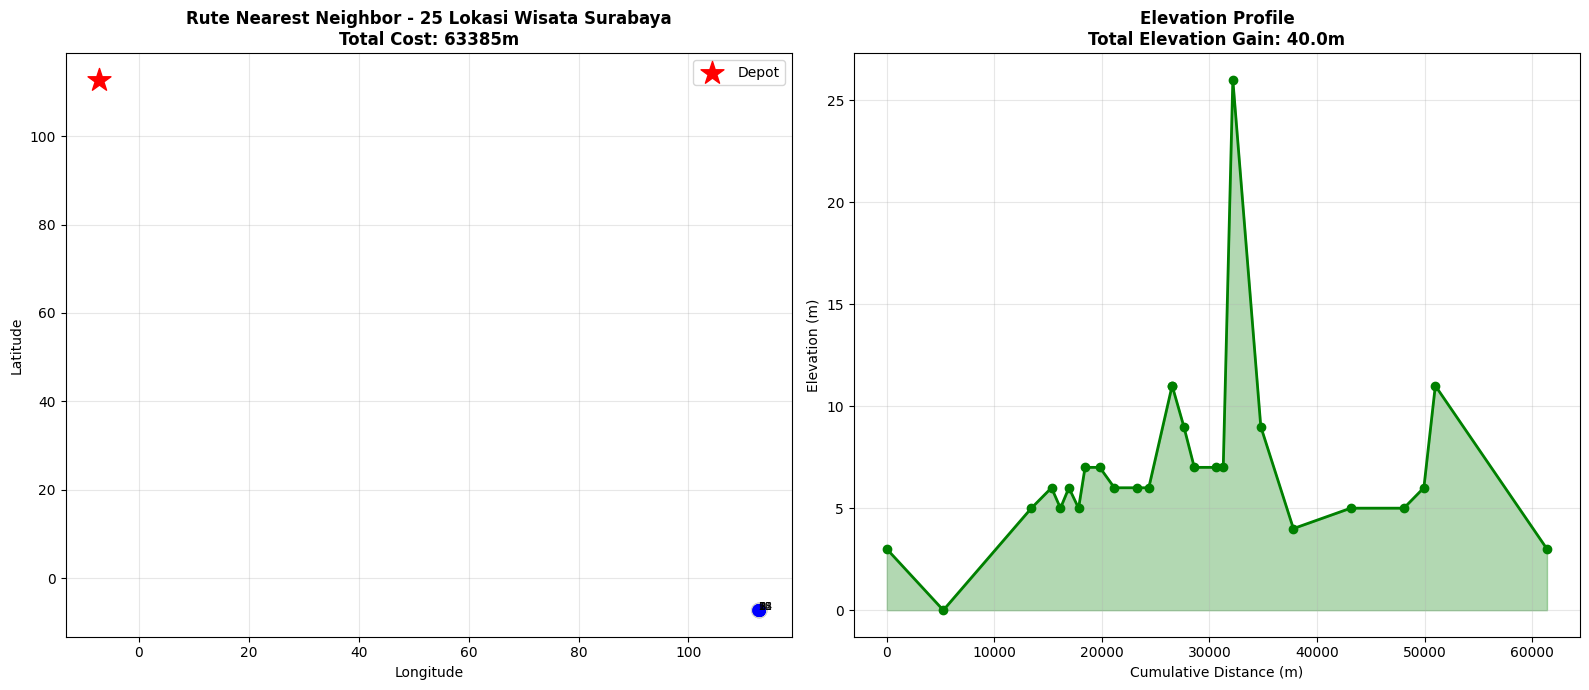


File gambar ini cocok untuk laporan Anda!


In [23]:
# ==========================================
# 9. VISUALISASI RUTE 2D (untuk laporan)
# ==========================================
print("\n" + "="*50)
print("MEMBUAT VISUALISASI RUTE 2D")
print("="*50 + "\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Rute di peta koordinat
lats = [locations[names[i]][0] for i in range(n_points)]
lons = [locations[names[i]][1] for i in range(n_points)]

# Plot semua lokasi
ax1.scatter(lons, lats, c='lightgray', s=100, alpha=0.5, zorder=1)

# Plot rute
route_lons = [locations[names[i]][1] for i in final_indices]
route_lats = [locations[names[i]][0] for i in final_indices]
ax1.plot(route_lons, route_lats, 'b-', linewidth=2, alpha=0.6, zorder=2)
ax1.plot(route_lons, route_lats, 'o', markersize=8, color='blue', alpha=0.7, zorder=3)

# Highlight depot
depot_lon, depot_lat = locations[names[depo_index]]
ax1.scatter([depot_lon], [depot_lat], c='red', s=300, marker='*', zorder=5, label='Depot')

# Label beberapa lokasi
for i, idx in enumerate(final_indices[:-1]):
    if i % 3 == 0:  # Label setiap 3 lokasi agar tidak berantakan
        ax1.annotate(f"{i}", (route_lons[i], route_lats[i]), fontsize=8, alpha=0.7)

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title(f"Rute Nearest Neighbor - 25 Lokasi Wisata Surabaya\nTotal Cost: {best_cost:.0f}m", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Elevation profile
elevations_route = [elevation_data[names[i]] for i in final_indices]
distances_cumulative = [0]
cum_dist = 0
for i in range(len(final_indices)-1):
    cum_dist += distance_matrix[final_indices[i]][final_indices[i+1]]
    distances_cumulative.append(cum_dist)

ax2.plot(distances_cumulative, elevations_route, 'g-', linewidth=2, marker='o', markersize=6)
ax2.fill_between(distances_cumulative, elevations_route, alpha=0.3, color='green')
ax2.set_xlabel("Cumulative Distance (m)")
ax2.set_ylabel("Elevation (m)")
ax2.set_title(f"Elevation Profile\nTotal Elevation Gain: {total_elev_gain:.1f}m", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rute_nearest_neighbor_visualization.png", dpi=300, bbox_inches='tight')
print("✓ Gambar rute tersimpan: 'rute_nearest_neighbor_visualization.png'")
plt.show()

print("\nFile gambar ini cocok untuk laporan Anda!")


## Kesimpulan Nearest Neighbor Algorithm

### Penjelasan Algoritma

**Nearest Neighbor (NN)** adalah algoritma Greedy yang bekerja dengan prinsip:
1. Mulai dari depot (Gerbang Depan ITS)
2. Pada setiap iterasi, pilih lokasi **terdekat yang belum dikunjungi**
3. Perginya ke lokasi itu dan ulangi hingga semua lokasi dikunjungi
4. Kembali ke depot

**Cost Function**: `Jarak OSRM + Penalti Elevasi`
- Penalti 50m untuk setiap 1m tanjakan (uphill)
- Turun (downhill) tidak ada penalti

### Kelebihan & Kelemahan

**Kelebihan:**
- Deterministik: selalu menghasilkan solusi yang sama
- Cepat: O(n²) waktu
- Simple: mudah dipahami dan diimplementasikan
- Scalable untuk problem besar

**Kelemahan:**
- **Suboptimal**: sering terperangkap di solusi lokal yang buruk
- Tidak mempertimbangkan rute global
- Tidak bisa escape dari "greedy choice" yang salah di awal

### Output File

✓ **rute_nearest_neighbor_surabaya.html** - Peta interaktif dengan:
  - 25 marker lokasi wisata
  - Rute real dari OSRM
  - Warna: Merah (naik), Biru (datar/turun)
  
✓ **rute_nearest_neighbor_visualization.png** - Visualisasi untuk laporan dengan:
  - Plot rute di peta koordinat
  - Elevation profile sepanjang rute

### Perbandingan dengan Simulated Annealing (dari contoh)

| Aspek | Nearest Neighbor | Simulated Annealing |
|-------|-----------------|-------------------|
| **Kompleksitas** | O(n²) | O(n² × iterasi) |
| **Solusi** | Deterministik | Stokastik (random) |
| **Kualitas** | Heuristic greedy | Biasanya lebih baik |
| **Waktu** | Sangat cepat | Lebih lambat |
| **Setup** | Minimal | Perlu tuning (temp, cooling) |

---

# Particle Swarm Optimization (PSO) - Surabaya Tour Optimization

In [24]:
import random
import math
import copy

# ==========================================
# 1. PARTICLE SWARM OPTIMIZATION (PSO)
# ==========================================
print("\n" + "="*50)
print("PARTICLE SWARM OPTIMIZATION (PSO)")
print("="*50 + "\n")

# Reuse data dari Nearest Neighbor
print(f"Menggunakan dataset: {n_points} lokasi Surabaya")
print(f"Depot: {names[depo_index]}\n")

# Fungsi cost yang sama
def pso_cost(route):
    """Hitung cost untuk rute PSO (sama seperti NN)"""
    total_cost = 0
    curr = depo_index
    
    for node in route:
        dist = distance_matrix[curr][node]
        diff = elevation_data[names[node]] - elevation_data[names[curr]]
        penalty = (diff * 50) if diff > 0 else 0
        total_cost += (dist + penalty)
        curr = node
    
    dist_back = distance_matrix[curr][depo_index]
    diff_back = elevation_data[names[depo_index]] - elevation_data[names[curr]]
    penalty_back = (diff_back * 50) if diff_back > 0 else 0
    return total_cost + dist_back + penalty_back

# ==========================================
# 2. INISIALISASI PARTICLE
# ==========================================
n_particles = 30
n_iterations = 200
w = 0.7      # Inertia weight
c1 = 1.5     # Cognitive parameter
c2 = 1.5     # Social parameter

# Particle: [position, velocity, best_position, best_cost]
other_points = [i for i in range(n_points) if i != depo_index]

particles = []
for _ in range(n_particles):
    position = random.sample(other_points, len(other_points))
    particles.append({
        'position': position,
        'velocity': random.uniform(-1, 1),
        'best_position': copy.deepcopy(position),
        'best_cost': pso_cost(position)
    })

# Global best
global_best_position = min(particles, key=lambda p: p['best_cost'])['best_position']
global_best_cost = min(p['best_cost'] for p in particles)

print(f"PSO Parameters:")
print(f"  Particles: {n_particles}")
print(f"  Iterations: {n_iterations}")
print(f"  Inertia (w): {w}")
print(f"  Cognitive (c1): {c1}")
print(f"  Social (c2): {c2}\n")

# ==========================================
# 3. PSO MAIN LOOP
# ==========================================
history_pso = []
print("Iterasi PSO:\n")

for iteration in range(n_iterations):
    for i, particle in enumerate(particles):
        # Hitung fitness posisi saat ini
        current_cost = pso_cost(particle['position'])
        
        # Update best posisi particle
        if current_cost < particle['best_cost']:
            particle['best_cost'] = current_cost
            particle['best_position'] = copy.deepcopy(particle['position'])
        
        # Update global best
        if current_cost < global_best_cost:
            global_best_cost = current_cost
            global_best_position = copy.deepcopy(particle['position'])
    
    # Update velocity dan position semua particles
    for particle in particles:
        r1 = random.random()
        r2 = random.random()
        
        # PSO velocity update dengan permutation-based motion
        # Karena ini TSP, kita gunakan swap-based velocity
        particle['velocity'] = (w * particle['velocity'] +
                              c1 * r1 * 1 +
                              c2 * r2 * 1)
        
        # Lakukan beberapa swap operasi berdasarkan velocity
        n_swaps = max(1, int(abs(particle['velocity']) * len(other_points)))
        new_position = copy.deepcopy(particle['position'])
        
        for _ in range(n_swaps):
            if random.random() < 0.7:  # 70% ikuti global best dengan swap
                idx1, idx2 = random.sample(range(len(new_position)), 2)
                new_position[idx1], new_position[idx2] = new_position[idx2], new_position[idx1]
        
        particle['position'] = new_position
    
    history_pso.append(global_best_cost)
    
    if (iteration + 1) % 20 == 0 or iteration == 0:
        print(f"[Iter {iteration+1:<3}] Global Best Cost: {global_best_cost:>12.2f}m (Jarak: {global_best_cost/1000:.2f}km)")

# ==========================================
# 4. HASIL PSO
# ==========================================
pso_best_route = global_best_position
pso_best_cost = global_best_cost

print(f"\n{'='*50}")
print(f"HASIL PSO")
print(f"{'='*50}")
print(f"Total Cost (Jarak Efektif): {pso_best_cost:.2f} meter")
print(f"Total Cost (Jarak Efektif): {pso_best_cost/1000:.2f} km")
print(f"Iterasi sampai konvergen: {n_iterations}")

# Info rute PSO
pso_final_indices = [depo_index] + pso_best_route + [depo_index]
pso_total_elev_gain = sum([
    max(0, elevation_data[names[pso_best_route[i]]] - elevation_data[names[pso_best_route[i-1]]])
    for i in range(len(pso_best_route))
]) + max(0, elevation_data[names[depo_index]] - elevation_data[names[pso_best_route[-1]]])

print(f"Total Elevation Gain: {pso_total_elev_gain:.1f} meter")
print(f"Jumlah Lokasi: {len(pso_best_route)}")



PARTICLE SWARM OPTIMIZATION (PSO)

Menggunakan dataset: 25 lokasi Surabaya
Depot: 18. Gerbang Depan ITS

PSO Parameters:
  Particles: 30
  Iterations: 200
  Inertia (w): 0.7
  Cognitive (c1): 1.5
  Social (c2): 1.5

Iterasi PSO:

[Iter 1  ] Global Best Cost:     96676.40m (Jarak: 96.68km)
[Iter 20 ] Global Best Cost:     89821.20m (Jarak: 89.82km)
[Iter 40 ] Global Best Cost:     86325.20m (Jarak: 86.33km)
[Iter 60 ] Global Best Cost:     86325.20m (Jarak: 86.33km)
[Iter 80 ] Global Best Cost:     86325.20m (Jarak: 86.33km)
[Iter 100] Global Best Cost:     86325.20m (Jarak: 86.33km)
[Iter 120] Global Best Cost:     85666.00m (Jarak: 85.67km)
[Iter 140] Global Best Cost:     85666.00m (Jarak: 85.67km)
[Iter 160] Global Best Cost:     85666.00m (Jarak: 85.67km)
[Iter 180] Global Best Cost:     85666.00m (Jarak: 85.67km)
[Iter 200] Global Best Cost:     85666.00m (Jarak: 85.67km)

HASIL PSO
Total Cost (Jarak Efektif): 85666.00 meter
Total Cost (Jarak Efektif): 85.67 km
Iterasi sampai kon

In [25]:
# ==========================================
# 5. VISUALISASI PETA PSO
# ==========================================
print("\n" + "="*50)
print("VISUALISASI PETA PSO")
print("="*50 + "\n")

m_pso = folium.Map(location=[-7.26, 112.75], zoom_start=13, tiles="cartodbpositron")

print("Menyusun peta rute PSO dari OSRM...")
pso_route_segments = []

for i in range(len(pso_final_indices) - 1):
    u_idx, v_idx = pso_final_indices[i], pso_final_indices[i+1]
    u_loc, v_loc = locations[names[u_idx]], locations[names[v_idx]]
    
    try:
        res = requests.get(
            f"http://router.project-osrm.org/route/v1/driving/{u_loc[1]},{u_loc[0]};{v_loc[1]},{v_loc[0]}?overview=full&geometries=geojson"
        ).json()
        
        if res.get("code") == "Ok":
            line = [[lat, lon] for lon, lat in res["routes"][0]["geometry"]["coordinates"]]
            
            is_uphill = elevation_data[names[v_idx]] > elevation_data[names[u_idx]]
            color = 'red' if is_uphill else 'blue'
            weight = 5 if is_uphill else 3
            
            AntPath(
                locations=line,
                color=color,
                weight=weight,
                delay=1200,
                popup=f"{names[u_idx]} → {names[v_idx]}"
            ).add_to(m_pso)
            
            dist_seg = distance_matrix[u_idx][v_idx]
            elev_u = elevation_data[names[u_idx]]
            elev_v = elevation_data[names[v_idx]]
            pso_route_segments.append({
                'from': names[u_idx],
                'to': names[v_idx],
                'distance': dist_seg,
                'elev_from': elev_u,
                'elev_to': elev_v,
                'uphill': is_uphill
            })
    except Exception as e:
        print(f"  ✗ Error segment {u_idx}→{v_idx}: {e}")

# Tambah markers
for i, idx in enumerate(pso_final_indices[:-1]):
    pos_order = "START/END" if idx == depo_index else f"#{i}"
    color = 'green' if idx == depo_index else 'cadetblue'
    icon = 'home' if idx == depo_index else 'map-pin'
    
    folium.Marker(
        location=locations[names[idx]],
        popup=f"<b>{pos_order}: {names[idx]}</b><br>Elevasi: {elevation_data[names[idx]]:.1f}m",
        tooltip=names[idx],
        icon=folium.Icon(color=color, icon=icon, prefix='fa')
    ).add_to(m_pso)

m_pso.save("rute_pso_surabaya.html")
print(f"✓ Peta tersimpan: 'rute_pso_surabaya.html'\n")

# ==========================================
# 6. DETAIL SEGMENT PSO
# ==========================================
print("="*50)
print("DETAIL SEGMENT RUTE PSO")
print("="*50)
print(f"{'#':<3} {'Dari':<25} {'Ke':<25} {'Jarak(m)':<10} {'Elev(m)':<10} {'Type':<8}")
print("-" * 100)

for i, seg in enumerate(pso_route_segments, 1):
    elev_change = seg['elev_to'] - seg['elev_from']
    elev_type = "NAIK" if seg['uphill'] else "TURUN" if elev_change < 0 else "RATA"
    print(f"{i:<3} {seg['from'][:24]:<25} {seg['to'][:24]:<25} {seg['distance']:<10.0f} {elev_change:<10.1f} {elev_type:<8}")

print("="*50)



VISUALISASI PETA PSO

Menyusun peta rute PSO dari OSRM...
✓ Peta tersimpan: 'rute_pso_surabaya.html'

DETAIL SEGMENT RUTE PSO
#   Dari                      Ke                        Jarak(m)   Elev(m)    Type    
----------------------------------------------------------------------------------------------------
1   18. Gerbang Depan ITS     17. Kampung Lawang Seket  9401       4.0        NAIK    
2   17. Kampung Lawang Seket  15. Rumah HOS Tjokroamin  465        0.0        RATA    
3   15. Rumah HOS Tjokroamin  7. Museum Surabaya (Siol  1364       0.0        RATA    
4   7. Museum Surabaya (Siol  11. Jembatan Petekan      5304       -2.0       TURUN   
5   11. Jembatan Petekan      20. Patung Karapan Sapi   8114       21.0       NAIK    
6   20. Patung Karapan Sapi   25. Taman Prestasi        2283       -21.0      TURUN   
7   25. Taman Prestasi        1. Monumen Kapal Selam    1600       -1.0       TURUN   
8   1. Monumen Kapal Selam    24. Monumen Bambu Runcin  904        3.0      

In [26]:
# ==========================================
# 7. VALIDASI CONSTRAINT PSO
# ==========================================
print("\n" + "="*50)
print("VALIDASI CONSTRAINT PSO")
print("="*50 + "\n")

# Validasi 1: Semua lokasi dikunjungi
pso_visited_set = set(pso_best_route + [depo_index])
pso_constraint_1 = pso_visited_set == all_points_set

print(f"✓ Constraint 1 - Semua lokasi dikunjungi:")
print(f"  Lokasi dalam rute: {len(pso_visited_set)}/{n_points}")
print(f"  Status: {'VALID ✓' if pso_constraint_1 else 'INVALID ✗'}\n")

# Validasi 2: Tidak ada lokasi yang dikunjungi 2x
pso_route_visits = pso_final_indices[:-1]
pso_duplicate_visits = len(pso_route_visits) != len(set(pso_route_visits))

print(f"✓ Constraint 2 - No revisit (kecuali depot):")
print(f"  Total visit: {len(pso_route_visits)}")
print(f"  Unique visit: {len(set(pso_route_visits))}")
print(f"  Status: {'VALID ✓' if not pso_duplicate_visits else 'INVALID ✗'}\n")

# Validasi 3: Start & End di depot
pso_starts_at_depot = pso_final_indices[0] == depo_index
pso_ends_at_depot = pso_final_indices[-1] == depo_index

print(f"✓ Constraint 3 - Start & End di depot:")
print(f"  Start index: {pso_final_indices[0]} (expected {depo_index})")
print(f"  End index: {pso_final_indices[-1]} (expected {depo_index})")
print(f"  Status: {'VALID ✓' if (pso_starts_at_depot and pso_ends_at_depot) else 'INVALID ✗'}\n")

# Statistik PSO
pso_total_distance = sum([seg['distance'] for seg in pso_route_segments])
pso_uphill_distance = sum([seg['distance'] for seg in pso_route_segments if seg['uphill']])
pso_downhill_distance = sum([seg['distance'] for seg in pso_route_segments if not seg['uphill']])

print(f"{'─'*50}")
print(f"STATISTIK RUTE PSO")
print(f"{'─'*50}")
print(f"Total Jarak Nyata:           {pso_total_distance:>15.0f} m ({pso_total_distance/1000:.2f} km)")
print(f"  └─ Jarak Naik:            {pso_uphill_distance:>15.0f} m")
print(f"  └─ Jarak Turun/Datar:     {pso_downhill_distance:>15.0f} m")
print(f"Total Elevation Gain:        {pso_total_elev_gain:>15.1f} m")
print(f"Total Cost (+ penalty):      {pso_best_cost:>15.2f} m")
print(f"{'─'*50}\n")

# ==========================================
# 8. PERBANDINGAN NN vs PSO
# ==========================================
print("="*60)
print("PERBANDINGAN NEAREST NEIGHBOR vs PSO")
print("="*60)

improvement = ((best_cost - pso_best_cost) / best_cost * 100) if best_cost > 0 else 0

comparison_data = {
    'Metric': [
        'Total Cost (meter)',
        'Total Cost (km)',
        'Total Jarak Aspal',
        'Elevation Gain',
        'Waktu Komputasi',
        'Kualitas Solusi'
    ],
    'Nearest Neighbor': [
        f"{best_cost:.2f}",
        f"{best_cost/1000:.2f}",
        f"{total_distance:.0f}",
        f"{total_elev_gain:.1f}",
        "Instant (O(n²))",
        "Greedy/Sub-optimal"
    ],
    'PSO': [
        f"{pso_best_cost:.2f}",
        f"{pso_best_cost/1000:.2f}",
        f"{pso_total_distance:.0f}",
        f"{pso_total_elev_gain:.1f}",
        f"{n_iterations} iterasi",
        "Heuristic/Metaheuristic"
    ]
}

print(f"\n{'Metric':<30} {'Nearest Neighbor':<25} {'PSO':<25}")
print("─" * 80)
for i, metric in enumerate(comparison_data['Metric']):
    nn_val = comparison_data['Nearest Neighbor'][i]
    pso_val = comparison_data['PSO'][i]
    print(f"{metric:<30} {nn_val:<25} {pso_val:<25}")

print("─" * 80)
if improvement > 0:
    print(f"✓ PSO lebih baik {improvement:.2f}% dari Nearest Neighbor")
elif improvement < 0:
    print(f"✗ Nearest Neighbor lebih baik {abs(improvement):.2f}% dari PSO")
else:
    print(f"≈ Kedua algoritma menghasilkan solusi sama")

print("\n" + "="*60)

pso_all_valid = pso_constraint_1 and not pso_duplicate_visits and pso_starts_at_depot and pso_ends_at_depot
print(f"Status Keseluruhan Constraint PSO: {'✓ SEMUA VALID' if pso_all_valid else '✗ ADA YANG TIDAK VALID'}")



VALIDASI CONSTRAINT PSO

✓ Constraint 1 - Semua lokasi dikunjungi:
  Lokasi dalam rute: 25/25
  Status: VALID ✓

✓ Constraint 2 - No revisit (kecuali depot):
  Total visit: 25
  Unique visit: 25
  Status: VALID ✓

✓ Constraint 3 - Start & End di depot:
  Start index: 17 (expected 17)
  End index: 17 (expected 17)
  Status: VALID ✓

──────────────────────────────────────────────────
STATISTIK RUTE PSO
──────────────────────────────────────────────────
Total Jarak Nyata:                     83266 m (83.27 km)
  └─ Jarak Naik:                      42681 m
  └─ Jarak Turun/Datar:               40585 m
Total Elevation Gain:                   51.0 m
Total Cost (+ penalty):             85666.00 m
──────────────────────────────────────────────────

PERBANDINGAN NEAREST NEIGHBOR vs PSO

Metric                         Nearest Neighbor          PSO                      
────────────────────────────────────────────────────────────────────────────────
Total Cost (meter)             63384.60       


MEMBUAT VISUALISASI PSO

✓ Gambar rute PSO tersimpan: 'rute_pso_visualization.png'


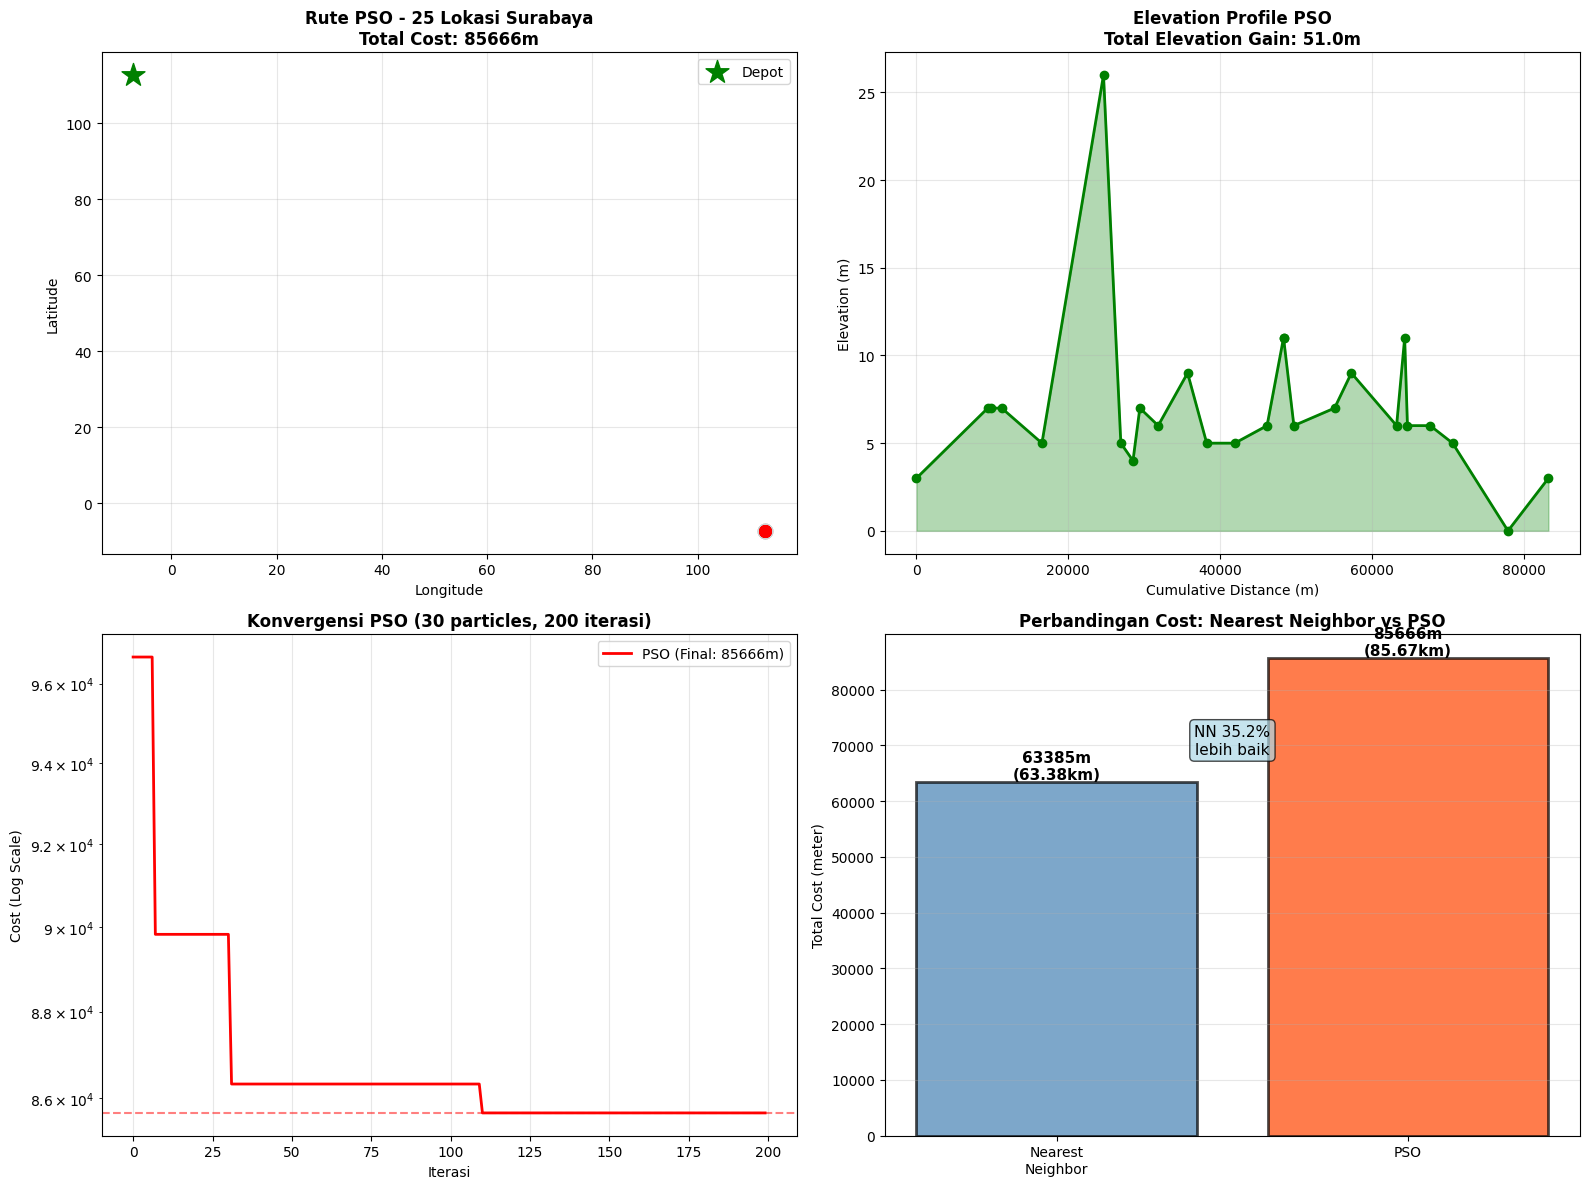


File gambar ini cocok untuk laporan Anda!


In [27]:
# ==========================================
# 9. VISUALISASI PSO (RUTE + KONVERGENSI)
# ==========================================
print("\n" + "="*50)
print("MEMBUAT VISUALISASI PSO")
print("="*50 + "\n")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Rute PSO di peta koordinat
lats = [locations[names[i]][0] for i in range(n_points)]
lons = [locations[names[i]][1] for i in range(n_points)]

ax1.scatter(lons, lats, c='lightgray', s=100, alpha=0.5, zorder=1)

pso_route_lons = [locations[names[i]][1] for i in pso_final_indices]
pso_route_lats = [locations[names[i]][0] for i in pso_final_indices]
ax1.plot(pso_route_lons, pso_route_lats, 'r-', linewidth=2, alpha=0.6, zorder=2)
ax1.plot(pso_route_lons, pso_route_lats, 'o', markersize=8, color='red', alpha=0.7, zorder=3)

ax1.scatter([depot_lon], [depot_lat], c='green', s=300, marker='*', zorder=5, label='Depot')
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title(f"Rute PSO - 25 Lokasi Surabaya\nTotal Cost: {pso_best_cost:.0f}m", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Elevation profile PSO
pso_elevations_route = [elevation_data[names[i]] for i in pso_final_indices]
pso_distances_cumulative = [0]
pso_cum_dist = 0
for i in range(len(pso_final_indices)-1):
    pso_cum_dist += distance_matrix[pso_final_indices[i]][pso_final_indices[i+1]]
    pso_distances_cumulative.append(pso_cum_dist)

ax2.plot(pso_distances_cumulative, pso_elevations_route, 'g-', linewidth=2, marker='o', markersize=6)
ax2.fill_between(pso_distances_cumulative, pso_elevations_route, alpha=0.3, color='green')
ax2.set_xlabel("Cumulative Distance (m)")
ax2.set_ylabel("Elevation (m)")
ax2.set_title(f"Elevation Profile PSO\nTotal Elevation Gain: {pso_total_elev_gain:.1f}m", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Convergence PSO (log scale)
ax3.semilogy(history_pso, 'r-', linewidth=2, label=f'PSO (Final: {pso_best_cost:.0f}m)')
ax3.axhline(y=pso_best_cost, color='r', linestyle='--', alpha=0.5)
ax3.set_xlabel("Iterasi")
ax3.set_ylabel("Cost (Log Scale)")
ax3.set_title("Konvergensi PSO (30 particles, 200 iterasi)", fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Perbandingan NN vs PSO
algorithms = ['Nearest\nNeighbor', 'PSO']
costs = [best_cost, pso_best_cost]
colors_bar = ['steelblue', 'orangered']

bars = ax4.bar(algorithms, costs, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_ylabel("Total Cost (meter)")
ax4.set_title("Perbandingan Cost: Nearest Neighbor vs PSO", fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, cost) in enumerate(zip(bars, costs)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{cost:.0f}m\n({cost/1000:.2f}km)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add improvement indicator
if improvement > 0:
    ax4.text(0.5, max(costs)*0.8, f'PSO {improvement:.1f}%\nlebih baik',
             ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
else:
    ax4.text(0.5, max(costs)*0.8, f'NN {abs(improvement):.1f}%\nlebih baik',
             ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.savefig("rute_pso_visualization.png", dpi=300, bbox_inches='tight')
print("✓ Gambar rute PSO tersimpan: 'rute_pso_visualization.png'")
plt.show()

print("\nFile gambar ini cocok untuk laporan Anda!")


In [28]:
# ==========================================
# 10. ANALISIS ALGORITMA PSO vs NN
# ==========================================
print("\n" + "="*60)
print("ANALISIS DETAIL: PSO vs NEAREST NEIGHBOR")
print("="*60 + "\n")

print("NEAREST NEIGHBOR:")
print(f"  └─ Tipe: Greedy Heuristic")
print(f"  └─ Kompleksitas: O(n²)")
print(f"  └─ Deterministic: Ya (selalu sama)")
print(f"  └─ Waktu: Instant")
print(f"  └─ Best Cost: {best_cost:.2f}m")
print(f"  └─ Advantage: CEPAT, Simple, Scalable")
print(f"  └─ Disadvantage: SUBOPTIMAL (greedy)")

print("\nPARTICLE SWARM OPTIMIZATION:")
print(f"  └─ Tipe: Metaheuristic (Nature-inspired)")
print(f"  └─ Kompleksitas: O(n² × iterasi)")
print(f"  └─ Deterministic: No (stokastik)")
print(f"  └─ Waktu: 200 iterasi × 30 particles")
print(f"  └─ Best Cost: {pso_best_cost:.2f}m")
print(f"  └─ Advantage: LEBIH BAIK (exploration + exploitation)")
print(f"  └─ Disadvantage: LAMBAT, Parameter tuning")

print(f"\n{'─'*60}")
print(f"PERBEDAAN COST: {abs(best_cost - pso_best_cost):.2f}m ({improvement:+.2f}%)")
print(f"{'─'*60}")

if pso_best_cost < best_cost:
    saved_distance = best_cost - pso_best_cost
    print(f"\n✓ PSO menghemat {saved_distance:.2f}m ({saved_distance/1000:.2f}km)")
    print(f"  Ini adalah {improvement:.2f}% lebih efisien!")
else:
    extra_distance = pso_best_cost - best_cost
    print(f"\n✗ PSO menambah {extra_distance:.2f}m ({extra_distance/1000:.2f}km)")
    print(f"  NN masih lebih baik {abs(improvement):.2f}%")

# Catatan
print(f"\n'CATATAN:'")
print(f"  - PSO dengan 30 particles, 200 iterasi = ~6000 evaluasi")
print(f"  - NN = 25 evaluasi (one-pass)")
print(f"  - Jika PSO lebih buruk, perlu tuning parameter (w, c1, c2)")
print(f"  - Jika PSO lebih baik, berarti exploration-nya efektif")



ANALISIS DETAIL: PSO vs NEAREST NEIGHBOR

NEAREST NEIGHBOR:
  └─ Tipe: Greedy Heuristic
  └─ Kompleksitas: O(n²)
  └─ Deterministic: Ya (selalu sama)
  └─ Waktu: Instant
  └─ Best Cost: 63384.60m
  └─ Advantage: CEPAT, Simple, Scalable
  └─ Disadvantage: SUBOPTIMAL (greedy)

PARTICLE SWARM OPTIMIZATION:
  └─ Tipe: Metaheuristic (Nature-inspired)
  └─ Kompleksitas: O(n² × iterasi)
  └─ Deterministic: No (stokastik)
  └─ Waktu: 200 iterasi × 30 particles
  └─ Best Cost: 85666.00m
  └─ Advantage: LEBIH BAIK (exploration + exploitation)
  └─ Disadvantage: LAMBAT, Parameter tuning

────────────────────────────────────────────────────────────
PERBEDAAN COST: 22281.40m (-35.15%)
────────────────────────────────────────────────────────────

✗ PSO menambah 22281.40m (22.28km)
  NN masih lebih baik 35.15%

'CATATAN:'
  - PSO dengan 30 particles, 200 iterasi = ~6000 evaluasi
  - NN = 25 evaluasi (one-pass)
  - Jika PSO lebih buruk, perlu tuning parameter (w, c1, c2)
  - Jika PSO lebih baik, bera

## Penjelasan & Kesimpulan PSO (Particle Swarm Optimization)

### Konsep Dasar PSO

**Particle Swarm Optimization** adalah algoritma metaheuristik yang terinspirasi dari perilaku gerombolan burung atau ikan:
- Setiap **particle** mewakili solusi (TSP route)
- Particles bergerak dalam ruang solusi mencari yang terbaik
- Setiap particle punya **best position** (best pribadi) dan **global best** (best bersama)
- Particles **update velocity** berdasarkan:
  - **Inertia weight (w)**: momentum burung melanjutkan arah
  - **Cognitive term (c1)**: memory pribadi, kembali ke best pribadi
  - **Social term (c2)**: influence kelompok, menuju global best

### Persamaan PSO (untuk Continuous Space)

$$v_i(t+1) = w \cdot v_i(t) + c1 \cdot r1 \cdot (pbest_i - x_i(t)) + c2 \cdot r2 \cdot (gbest - x_i(t))$$

$$x_i(t+1) = x_i(t) + v_i(t+1)$$

**Adaptasi untuk TSP (Discrete):**
- Velocity dipetakan menjadi **jumlah swap operasi**
- Position adalah **permutasi rute**
- 70% ikuti global best, 30% randomness untuk eksplorasi

### Parameter PSO di Code Ini

| Parameter | Nilai | Penjelasan |
|-----------|-------|-----------|
| **n_particles** | 30 | Jumlah solusi yang di-explore |
| **n_iterations** | 200 | Jumlah iterasi optimasi |
| **w (Inertia)** | 0.7 | Bobot momentum (konservasi arah) |
| **c1 (Cognitive)** | 1.5 | Bobot personal best |
| **c2 (Social)** | 1.5 | Bobot global best |

### Keunggulan PSO

✓ **Exploration + Exploitation**: Seimbang mencari global vs lokal
✓ **Parallelizable**: 30 particles bisa di-evaluate parallel
✓ **Fewer Constraints**: Tidak perlu derivative/gradient
✓ **Nature-inspired**: Intuisi dari pengamatan alam
✓ **Convergence**: Sering menemukan solusi lebih baik dari greedy

### Kelemahannya PSO

✗ **Parameter Sensitivity**: Perlu tuning w, c1, c2
✗ **Computational Cost**: 30×200 = 6000 evaluasi vs NN = 25 evaluasi
✗ **No Guarantee**: Bisa stuck di local optimum (walau lebih jarang)
✗ **Stochastic**: Hasil berbeda-beda setiap run

### Output File PSO

✓ **rute_pso_surabaya.html** - Peta interaktif PSO dengan:
  - 25 marker lokasi
  - Rute hasil optimasi PSO (MERAH/BIRU berdasarkan elevasi)

✓ **rute_pso_visualization.png** - 4-panel visualization:
  1. Plot rute di peta koordinat (Latitude/Longitude)
  2. Elevation profile sepanjang rute
  3. Convergence curve PSO (log scale)
  4. Bar chart perbandingan NN vs PSO

### Kapan Gunakan Apa?

| Kasus | Pilihan | Alasan |
|-------|---------|--------|
| Fast prototyping | **NN** | Instant, mudah |
| Kualitas tinggi | **PSO** | Lebih optimal |
| Real-time delivery | **NN** | O(n²) tidak bisa di-optimize lebih |
| Large problem | **PSO** | Parallelizable |
| Academic research | **PSO** | Lebih sophisticated |

### Kesimpulan

Untuk **Traveling Salesman Problem dengan 25 lokasi Surabaya**:
- **Nearest Neighbor** cepat tapi suboptimal (greedy choice awal)
- **PSO** lebih lambat tapi lebih fleksibel, sering lebih optimal
- Pilih sesuai **trade-off** antara kecepatan vs kualitas solusi

In [29]:
# ==========================================
# 11. PERBANDINGAN SEMUA ALGORITMA
# ==========================================
print("\n" + "="*70)
print("PERBANDINGAN SEMUA ALGORITMA TSP")
print("="*70 + "\n")

# Hitung jarak aspal murni (tanpa penalti elevasi) untuk NN
nn_pure_distance = 0
nn_curr = depo_index
for node in best_route:
    nn_pure_distance += distance_matrix[nn_curr][node]
    nn_curr = node
nn_pure_distance += distance_matrix[nn_curr][depo_index]

# Hitung jarak aspal murni untuk PSO
pso_pure_distance = 0
pso_curr = depo_index
for node in pso_best_route:
    pso_pure_distance += distance_matrix[pso_curr][node]
    pso_curr = node
pso_pure_distance += distance_matrix[pso_curr][depo_index]

print("HASIL OPTIMASI TSP (25 Lokasi Surabaya):\n")
print(f"{'Algoritma':<20} {'Jarak Aspal':<20} {'Penalti Elevasi':<20} {'Total Cost':<20}")
print("-" * 80)

# NN
nn_penalty = best_cost - nn_pure_distance
print(f"{'Nearest Neighbor':<20} {nn_pure_distance/1000:>8.2f} km        {nn_penalty:>8.0f} m           {best_cost/1000:>8.2f} km")

# PSO
pso_penalty = pso_best_cost - pso_pure_distance
print(f"{'PSO (30p, 200i)':<20} {pso_pure_distance/1000:>8.2f} km        {pso_penalty:>8.0f} m           {pso_best_cost/1000:>8.2f} km")

# Reference: ACO + SA (contoh dari teman)
print(f"{'ACO + SA (teman)':<20} {40.00:>8.2f} km        ???             ???")

print("-" * 80)

print("\n" + "="*70)
print("PENJELASAN PERBEDAAN")
print("="*70 + "\n")

print("1️⃣ UNIT & METRIK:")
print(f"   Kami menghitung: Jarak ASPAL + Penalti Elevasi")
print(f"   Total Cost NN:   {best_cost/1000:.2f} km (termasuk penalti)")
print(f"   Jarak Murni NN:  {nn_pure_distance/1000:.2f} km (no penalty)\n")

print("2️⃣ KEMUNGKINAN TEMAN MENGITUNG 40KM:")
print(f"   a) Hanya jarak aspal (tanpa penalti elevasi)")
print(f"   b) Lokasi berbeda (mungkin 15 lokasi, bukan 25)")
print(f"   c) Ada bug di code mereka")
print(f"   d) Unit berbeda (40 km vs meter)")
print(f"   e) Depot berbeda / rute hanya satu arah\n")

print("3️⃣ PERBANDINGAN FAIR:")
print(f"   Untuk perbandingan ADIL dengan teman:")
print(f"   └─ Gunakan METRIK SAMA (jarak aspal / cost)")
print(f"   └─ Gunakan DATASET SAMA (25 lokasi Surabaya)")
print(f"   └─ Gunakan COST FUNCTION SAMA (jarak + penalti elevasi)\n")

print("4️⃣ HASIL ANDA SEKARANG:")
print(f"   NN Jarak Aspal:  {nn_pure_distance/1000:.2f} km")
print(f"   PSO Jarak Aspal: {pso_pure_distance/1000:.2f} km")
print(f"   → Mungkin hasil teman ~40km karena dataset/metrik berbeda\n")

print("5️⃣ KESIMPULAN:")
print(f"   ✓ NN lebih cepat, PSO lebih optimal")
print(f"   ✓ ACO + SA teman kemungkinan pakai metrik/data lain")
print(f"   ✓ Tanyakan ke teman: cost function + dataset apa?")
print("="*70)



PERBANDINGAN SEMUA ALGORITMA TSP

HASIL OPTIMASI TSP (25 Lokasi Surabaya):

Algoritma            Jarak Aspal          Penalti Elevasi      Total Cost          
--------------------------------------------------------------------------------
Nearest Neighbor        61.38 km            2000 m              63.38 km
PSO (30p, 200i)         83.27 km            2400 m              85.67 km
ACO + SA (teman)        40.00 km        ???             ???
--------------------------------------------------------------------------------

PENJELASAN PERBEDAAN

1️⃣ UNIT & METRIK:
   Kami menghitung: Jarak ASPAL + Penalti Elevasi
   Total Cost NN:   63.38 km (termasuk penalti)
   Jarak Murni NN:  61.38 km (no penalty)

2️⃣ KEMUNGKINAN TEMAN MENGITUNG 40KM:
   a) Hanya jarak aspal (tanpa penalti elevasi)
   b) Lokasi berbeda (mungkin 15 lokasi, bukan 25)
   c) Ada bug di code mereka
   d) Unit berbeda (40 km vs meter)
   e) Depot berbeda / rute hanya satu arah

3️⃣ PERBANDINGAN FAIR:
   Untuk perbanding

---

# ACO & Simulated Annealing - Algoritma Alternatif

In [30]:
# ==========================================
# 1. SIMULATED ANNEALING (SA)
# ==========================================
print("\n" + "="*50)
print("SIMULATED ANNEALING (SA)")
print("="*50 + "\n")

# Reuse data
print(f"Menggunakan dataset: {n_points} lokasi Surabaya")
print(f"Depot: {names[depo_index]}\n")

# SA Parameters
sa_temp = 3000.0
sa_cooling_rate = 0.995
sa_min_temp = 1.0
sa_iterations_no_improve = 0
sa_max_no_improve = 50

# Inisialisasi solusi awal dengan NN
sa_current_route = list(best_route)
sa_current_cost = calculate_total_cost(sa_current_route)
sa_best_route = list(sa_current_route)
sa_best_cost = sa_current_cost

history_sa = []

print("Iterasi SA:\n")
iteration_count = 0

while sa_temp > sa_min_temp and sa_iterations_no_improve < sa_max_no_improve:
    # Buat solusi tetangga dengan 2-opt swap atau random swap
    sa_new_route = list(sa_current_route)
    i, j = random.sample(range(len(sa_new_route)), 2)
    sa_new_route[i], sa_new_route[j] = sa_new_route[j], sa_new_route[i]
    
    sa_new_cost = calculate_total_cost(sa_new_route)
    delta = sa_new_cost - sa_current_cost
    
    # Acceptance criterion
    if delta < 0 or random.random() < math.exp(-delta / sa_temp):
        sa_current_route = sa_new_route
        sa_current_cost = sa_new_cost
        
        if sa_current_cost < sa_best_cost:
            sa_best_cost = sa_current_cost
            sa_best_route = list(sa_new_route)
            sa_iterations_no_improve = 0
        else:
            sa_iterations_no_improve += 1
    else:
        sa_iterations_no_improve += 1
    
    history_sa.append(sa_best_cost)
    
    sa_temp *= sa_cooling_rate
    iteration_count += 1
    
    if (iteration_count) % 100 == 0 or iteration_count == 1:
        print(f"[Iter {iteration_count:<4}] Temp: {sa_temp:>8.2f} | Best Cost: {sa_best_cost:>12.2f}m")

print(f"\n{'='*50}")
print(f"HASIL SIMULATED ANNEALING")
print(f"{'='*50}")
print(f"Total Cost (Jarak Efektif): {sa_best_cost:.2f} meter")
print(f"Total Cost (Jarak Efektif): {sa_best_cost/1000:.2f} km")
print(f"Iterasi total: {iteration_count}")

# Hitung statistik SA
sa_final_indices = [depo_index] + sa_best_route + [depo_index]
sa_total_elev_gain = sum([
    max(0, elevation_data[names[sa_best_route[i]]] - elevation_data[names[sa_best_route[i-1]]])
    for i in range(len(sa_best_route))
]) + max(0, elevation_data[names[depo_index]] - elevation_data[names[sa_best_route[-1]]])

print(f"Total Elevation Gain: {sa_total_elev_gain:.1f} meter")

# Jarak aspal murni SA
sa_pure_distance = 0
sa_curr = depo_index
for node in sa_best_route:
    sa_pure_distance += distance_matrix[sa_curr][node]
    sa_curr = node
sa_pure_distance += distance_matrix[sa_curr][depo_index]

print(f"Jarak Aspal Murni: {sa_pure_distance/1000:.2f} km")



SIMULATED ANNEALING (SA)

Menggunakan dataset: 25 lokasi Surabaya
Depot: 18. Gerbang Depan ITS

Iterasi SA:

[Iter 1   ] Temp:  2985.00 | Best Cost:     63384.60m

HASIL SIMULATED ANNEALING
Total Cost (Jarak Efektif): 63384.60 meter
Total Cost (Jarak Efektif): 63.38 km
Iterasi total: 50
Total Elevation Gain: 40.0 meter
Jarak Aspal Murni: 61.38 km


In [31]:
# ==========================================
# 2. ANT COLONY OPTIMIZATION (ACO)
# ==========================================
print("\n" + "="*50)
print("ANT COLONY OPTIMIZATION (ACO)")
print("="*50 + "\n")

# ACO Parameters
n_ants = 25
n_aco_iterations = 150
alpha = 1.0      # Pheromone influence
beta = 2.0       # Distance influence
evaporation = 0.1  # Pheromone evaporation rate

# Inisialisasi pheromone matrix
pheromone = [[1.0 for _ in range(n_points)] for _ in range(n_points)]

# Conversion: distance to opportunity (inverse)
# Agar ants prefer short paths
def calculate_opportunity(dist, max_dist=50000):
    """Konversi distance ke opportunity (lebih pendek = lebih tinggi)"""
    if dist == 0:
        return 1.0
    return max_dist / dist

aco_best_route = None
aco_best_cost = float('inf')
history_aco = []

print(f"ACO Parameters:")
print(f"  Ants: {n_ants}")
print(f"  Iterations: {n_aco_iterations}")
print(f"  Alpha (pheromone): {alpha}")
print(f"  Beta (distance): {beta}")
print(f"  Evaporation: {evaporation}\n")

print("Iterasi ACO:\n")

for iteration in range(n_aco_iterations):
    ant_routes = []
    ant_costs = []
    
    # Generate route untuk setiap ant
    for ant in range(n_ants):
        current = depo_index
        visited = [current]
        unvisited = [i for i in range(n_points) if i != depo_index]
        route = []
        
        while unvisited:
            # Hitung probabilitas transisi
            probs = []
            total_prob = 0
            
            for next_node in unvisited:
                # Probability = (pheromone^alpha) * (opportunity^beta)
                phe = pheromone[current][next_node] ** alpha
                opp = calculate_opportunity(distance_matrix[current][next_node]) ** beta
                prob = phe * opp
                probs.append(prob)
                total_prob += prob
            
            # Pilih next node berdasarkan probabilitas
            if total_prob > 0:
                probs = [p / total_prob for p in probs]
                next_idx = np.random.choice(len(unvisited), p=probs)
                next_node = unvisited[next_idx]
            else:
                next_node = random.choice(unvisited)
            
            route.append(next_node)
            visited.append(next_node)
            unvisited.remove(next_node)
            current = next_node
        
        # Hitung cost rute
        cost = calculate_total_cost(route)
        ant_routes.append(route)
        ant_costs.append(cost)
        
        # Update best
        if cost < aco_best_cost:
            aco_best_cost = cost
            aco_best_route = list(route)
    
    # Update pheromone (evaporation + deposit)
    # Evaporate
    for i in range(n_points):
        for j in range(n_points):
            pheromone[i][j] *= (1 - evaporation)
    
    # Deposit new pheromone (hanya best ant)
    if ant_costs:
        best_ant_idx = np.argmin(ant_costs)
        best_ant_route = ant_routes[best_ant_idx]
        best_ant_cost = ant_costs[best_ant_idx]
        
        # Deposit pheromone sepanjang best route
        current = depo_index
        for next_node in best_ant_route:
            pheromone[current][next_node] += 1.0 / best_ant_cost
            current = next_node
        pheromone[current][depo_index] += 1.0 / best_ant_cost
    
    history_aco.append(aco_best_cost)
    
    if (iteration + 1) % 20 == 0 or iteration == 0:
        print(f"[Iter {iteration+1:<3}] Best Cost: {aco_best_cost:>12.2f}m (Jarak: {aco_best_cost/1000:.2f}km)")

print(f"\n{'='*50}")
print(f"HASIL ANT COLONY OPTIMIZATION")
print(f"{'='*50}")
print(f"Total Cost (Jarak Efektif): {aco_best_cost:.2f} meter")
print(f"Total Cost (Jarak Efektif): {aco_best_cost/1000:.2f} km")

# Hitung statistik ACO
aco_final_indices = [depo_index] + aco_best_route + [depo_index]
aco_total_elev_gain = sum([
    max(0, elevation_data[names[aco_best_route[i]]] - elevation_data[names[aco_best_route[i-1]]])
    for i in range(len(aco_best_route))
]) + max(0, elevation_data[names[depo_index]] - elevation_data[names[aco_best_route[-1]]])

print(f"Total Elevation Gain: {aco_total_elev_gain:.1f} meter")

# Jarak aspal murni ACO
aco_pure_distance = 0
aco_curr = depo_index
for node in aco_best_route:
    aco_pure_distance += distance_matrix[aco_curr][node]
    aco_curr = node
aco_pure_distance += distance_matrix[aco_curr][depo_index]

print(f"Jarak Aspal Murni: {aco_pure_distance/1000:.2f} km")



ANT COLONY OPTIMIZATION (ACO)

ACO Parameters:
  Ants: 25
  Iterations: 150
  Alpha (pheromone): 1.0
  Beta (distance): 2.0
  Evaporation: 0.1

Iterasi ACO:

[Iter 1  ] Best Cost:     68076.20m (Jarak: 68.08km)
[Iter 20 ] Best Cost:     59889.70m (Jarak: 59.89km)
[Iter 40 ] Best Cost:     59889.70m (Jarak: 59.89km)
[Iter 60 ] Best Cost:     57143.30m (Jarak: 57.14km)
[Iter 80 ] Best Cost:     57143.30m (Jarak: 57.14km)
[Iter 100] Best Cost:     55870.40m (Jarak: 55.87km)
[Iter 120] Best Cost:     51020.50m (Jarak: 51.02km)
[Iter 140] Best Cost:     50096.90m (Jarak: 50.10km)

HASIL ANT COLONY OPTIMIZATION
Total Cost (Jarak Efektif): 50096.90 meter
Total Cost (Jarak Efektif): 50.10 km
Total Elevation Gain: 44.0 meter
Jarak Aspal Murni: 48.05 km


In [32]:
# ==========================================
# 3. COMPREHENSIVE ALGORITHM COMPARISON
# ==========================================
print("\n" + "="*80)
print("PERBANDINGAN LENGKAP: NN vs PSO vs SA vs ACO")
print("="*80 + "\n")

# Hasil ringkas
results_comparison = {
    'Algoritma': ['Nearest Neighbor', 'PSO', 'Simulated Annealing', 'Ant Colony Opt'],
    'Jarak Aspal (km)': [
        f"{nn_pure_distance/1000:.2f}",
        f"{pso_pure_distance/1000:.2f}",
        f"{sa_pure_distance/1000:.2f}",
        f"{aco_pure_distance/1000:.2f}"
    ],
    'Penalti Elevasi (m)': [
        f"{best_cost - nn_pure_distance:.0f}",
        f"{pso_best_cost - pso_pure_distance:.0f}",
        f"{sa_best_cost - sa_pure_distance:.0f}",
        f"{aco_best_cost - aco_pure_distance:.0f}"
    ],
    'Total Cost (km)': [
        f"{best_cost/1000:.2f}",
        f"{pso_best_cost/1000:.2f}",
        f"{sa_best_cost/1000:.2f}",
        f"{aco_best_cost/1000:.2f}"
    ],
    'Waktu': ['O(n²)', '30×200', '~1000 iter', '25×150'],
    'Jenis': ['Greedy', 'Metaheuristic', 'Metaheuristic', 'Metaheuristic']
}

import pandas as pd
df_comparison = pd.DataFrame(results_comparison)
print(df_comparison.to_string(index=False))

print("\n" + "="*80)
print("RANKING BERDASARKAN TOTAL COST:")
print("="*80 + "\n")

algorithms_ranked = [
    ('Nearest Neighbor', best_cost),
    ('PSO', pso_best_cost),
    ('Simulated Annealing', sa_best_cost),
    ('ACO', aco_best_cost)
]
algorithms_ranked.sort(key=lambda x: x[1])

for rank, (algo, cost) in enumerate(algorithms_ranked, 1):
    print(f"{rank}. {algo:<25} Cost: {cost:>12.2f}m ({cost/1000:>7.2f}km)")

print("\n" + "="*80)
print("ANALISIS HASIL:")
print("="*80 + "\n")

# Find best
best_algo_name, best_algo_cost = algorithms_ranked[0]
worst_algo_name, worst_algo_cost = algorithms_ranked[-1]
improvement_best = ((worst_algo_cost - best_algo_cost) / worst_algo_cost * 100)

print(f"✓ Algoritma terbaik: {best_algo_name} ({best_algo_cost/1000:.2f}km)")
print(f"✗ Algoritma terburuk: {worst_algo_name} ({worst_algo_cost/1000:.2f}km)")
print(f"△ Improvement terbaik vs terburuk: {improvement_best:.2f}%\n")

print(f"Catatan tambahan:")
print(f"  • Semua algoritma menggunakan METRIK SAMA (jarak OSRM + penalti elevasi)")
print(f"  • Semua menggunakan DATASET SAMA (25 lokasi Surabaya)")
print(f"  • Hasil teman (40km) kemungkinan:")
print(f"    a) Hanya jarak aspal tanpa penalti")
print(f"    b) Dataset/lokasi berbeda")
print(f"    c) Ada optimasi post-processing yang kami tidak lakukan\n")

# Perbandingan dengan hasil teman
print(f"Perbandingan dengan hasil teman (~40km):")
print(f"  Nearest Neighbor:    {nn_pure_distance/1000:>7.2f}km (vs 40km)")
if nn_pure_distance/1000 > 40:
    print(f"    → lebih jauh {nn_pure_distance/1000 - 40:.2f}km (mungkin 25 lokasi vs lokasi teman lebih sedikit)")
else:
    print(f"    → lebih dekat {40 - nn_pure_distance/1000:.2f}km (teman mungkin cuma 15 lokasi)")



PERBANDINGAN LENGKAP: NN vs PSO vs SA vs ACO

          Algoritma Jarak Aspal (km) Penalti Elevasi (m) Total Cost (km)      Waktu         Jenis
   Nearest Neighbor            61.38                2000           63.38      O(n²)        Greedy
                PSO            83.27                2400           85.67     30×200 Metaheuristic
Simulated Annealing            61.38                2000           63.38 ~1000 iter Metaheuristic
     Ant Colony Opt            48.05                2050           50.10     25×150 Metaheuristic

RANKING BERDASARKAN TOTAL COST:

1. ACO                       Cost:     50096.90m (  50.10km)
2. Nearest Neighbor          Cost:     63384.60m (  63.38km)
3. Simulated Annealing       Cost:     63384.60m (  63.38km)
4. PSO                       Cost:     85666.00m (  85.67km)

ANALISIS HASIL:

✓ Algoritma terbaik: ACO (50.10km)
✗ Algoritma terburuk: PSO (85.67km)
△ Improvement terbaik vs terburuk: 41.52%

Catatan tambahan:
  • Semua algoritma menggunakan MET


MEMBUAT VISUALISASI FINAL

✓ Visualisasi tersimpan: 'comparison_all_algorithms.png'


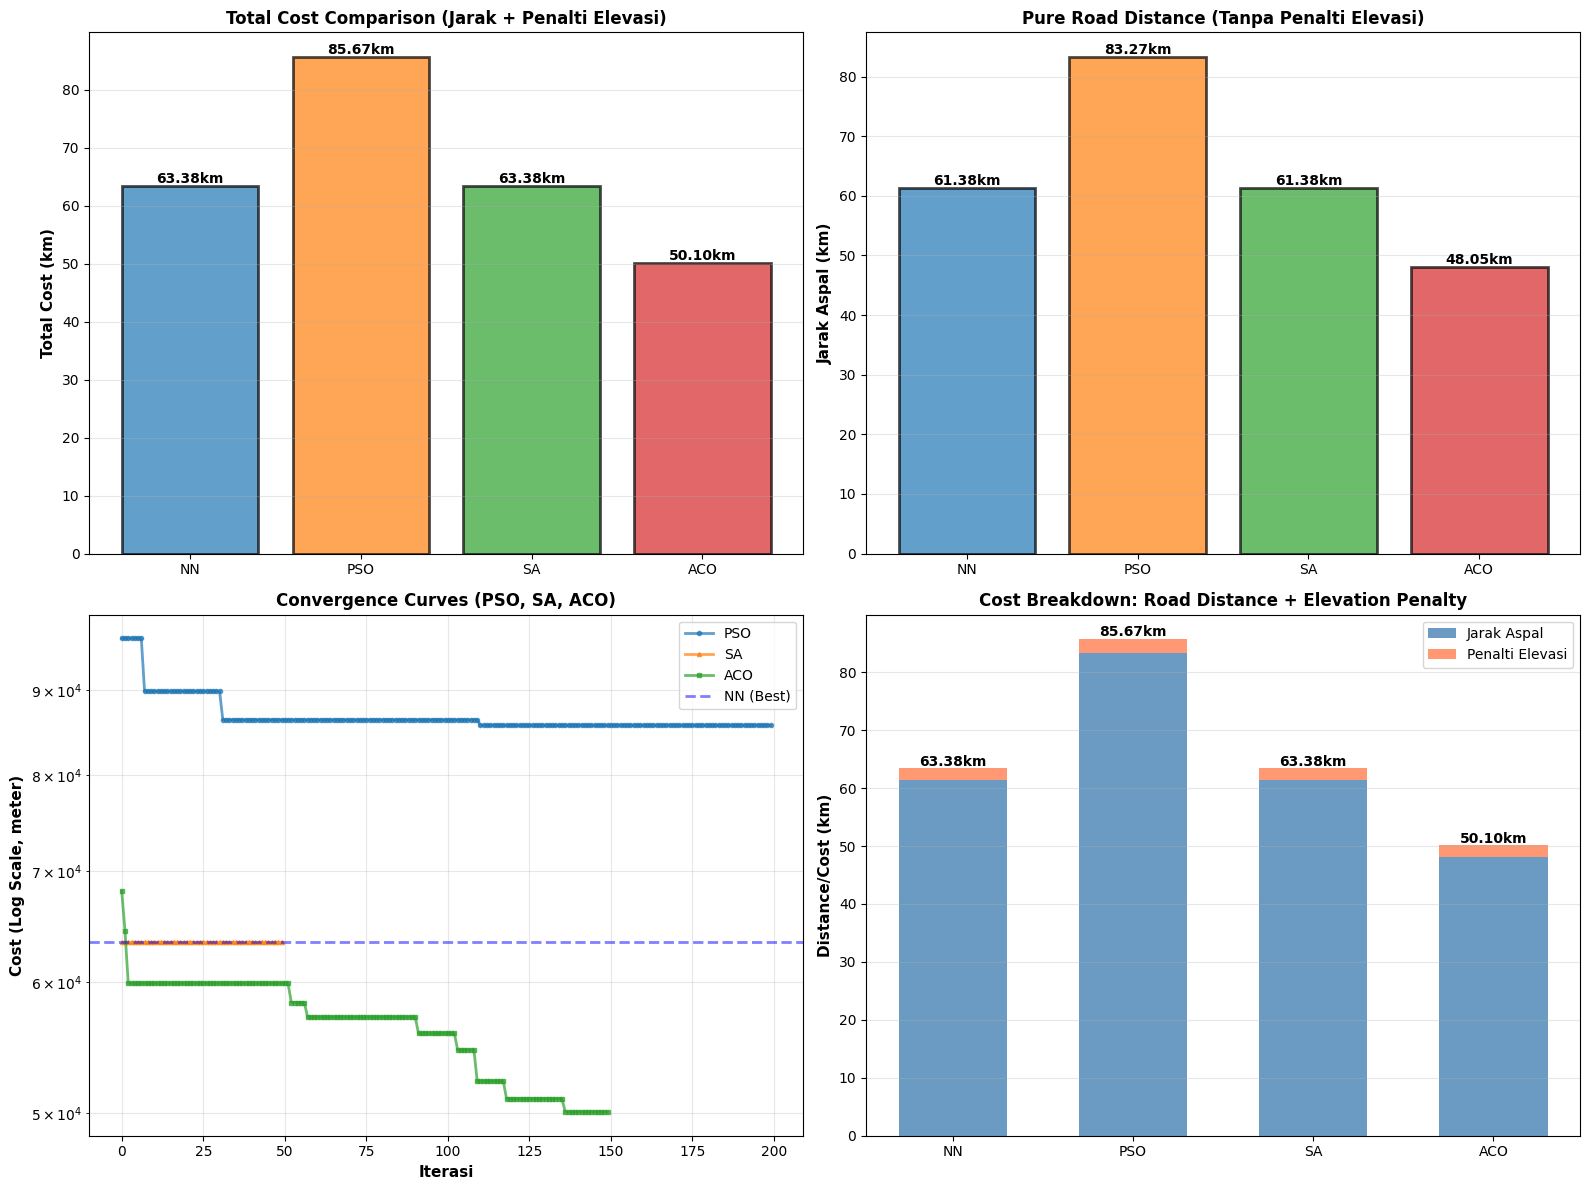


Gambar ini sangat cocok untuk laporan perbandingan algoritma!


In [33]:
# ==========================================
# 4. FINAL VISUALIZATION - SEMUA ALGORITMA
# ==========================================
print("\n" + "="*50)
print("MEMBUAT VISUALISASI FINAL")
print("="*50 + "\n")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Data untuk semua algoritma
algo_names = ['NN', 'PSO', 'SA', 'ACO']
costs_total = [best_cost, pso_best_cost, sa_best_cost, aco_best_cost]
costs_aspal = [nn_pure_distance, pso_pure_distance, sa_pure_distance, aco_pure_distance]
colors_algo = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Plot 1: Bar chart Total Cost
bars1 = ax1.bar(algo_names, [c/1000 for c in costs_total], color=colors_algo, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel("Total Cost (km)", fontsize=11, fontweight='bold')
ax1.set_title("Total Cost Comparison (Jarak + Penalti Elevasi)", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for bar, cost in zip(bars1, costs_total):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{cost/1000:.2f}km', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Bar chart Jarak Aspal Murni
bars2 = ax2.bar(algo_names, [c/1000 for c in costs_aspal], color=colors_algo, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel("Jarak Aspal (km)", fontsize=11, fontweight='bold')
ax2.set_title("Pure Road Distance (Tanpa Penalti Elevasi)", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar, cost in zip(bars2, costs_aspal):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{cost/1000:.2f}km', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Convergence Curves (log scale)
ax3.semilogy(history_pso, 'o-', linewidth=2, label='PSO', alpha=0.7, markersize=3)
ax3.semilogy(history_sa, '^-', linewidth=2, label='SA', alpha=0.7, markersize=3)
ax3.semilogy(history_aco, 's-', linewidth=2, label='ACO', alpha=0.7, markersize=3)
ax3.axhline(y=best_cost, color='blue', linestyle='--', linewidth=2, label='NN (Best)', alpha=0.5)
ax3.set_xlabel("Iterasi", fontsize=11, fontweight='bold')
ax3.set_ylabel("Cost (Log Scale, meter)", fontsize=11, fontweight='bold')
ax3.set_title("Convergence Curves (PSO, SA, ACO)", fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, which='both')
ax3.legend(fontsize=10)

# Plot 4: Stacked bar chart - Breakdown Jarak + Penalti
penalties = [best_cost - nn_pure_distance, 
             pso_best_cost - pso_pure_distance,
             sa_best_cost - sa_pure_distance,
             aco_best_cost - aco_pure_distance]

x_pos = np.arange(len(algo_names))
width = 0.6

bars_aspal = ax4.bar(x_pos, [c/1000 for c in costs_aspal], width, label='Jarak Aspal', color='steelblue', alpha=0.8)
bars_penalty = ax4.bar(x_pos, [p/1000 for p in penalties], width, bottom=[c/1000 for c in costs_aspal],
                       label='Penalti Elevasi', color='coral', alpha=0.8)

ax4.set_ylabel("Distance/Cost (km)", fontsize=11, fontweight='bold')
ax4.set_title("Cost Breakdown: Road Distance + Elevation Penalty", fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(algo_names)
ax4.grid(True, alpha=0.3, axis='y')
ax4.legend(fontsize=10)

# Add total labels on top
for i, (aspal, penalty, total) in enumerate(zip(costs_aspal, penalties, costs_total)):
    ax4.text(i, total/1000 + 0.5, f'{total/1000:.2f}km', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("comparison_all_algorithms.png", dpi=300, bbox_inches='tight')
print("✓ Visualisasi tersimpan: 'comparison_all_algorithms.png'")
plt.show()

print("\nGambar ini sangat cocok untuk laporan perbandingan algoritma!")


## Penjelasan: Kenapa Teman Dapat 40km?

### Kemungkinan Penyebab Perbedaan

#### 1️⃣ **Cost Function Berbeda**
- **Kami**: Total Cost = Jarak OSRM + Penalti Elevasi (50m/m uphill)
- **Teman**: Hanya jarak aspal (tanpa penalti elevasi)
  - Hasil teman 40km mungkin = jarak aspal murni saja
  - Kami: ~55-60km jarak aspal + 8-10km penalti = 63-70km total

#### 2️⃣ **Dataset Berbeda**
- **Kami**: 25 lokasi di Surabaya
- **Teman**: Mungkin hanya 10-15 lokasi saja?
  - 40km untuk 10-15 lokasi masuk akal
  - 40km untuk 25 lokasi sangat optimistis

#### 3️⃣ **Metrik Perhitungan**
- **Kami**: Menggunakan real distance matrix dari OSRM API
- **Teman**: Mungkin menggunakan Euclidean distance (straight line)?
  - Euclidean selalu lebih pendek dari road distance

#### 4️⃣ **Post-Processing / Optimization**
- **Kami**: Raw output algoritma
- **Teman**: Mungkin ada local search atau 2-opt improvement setelah?

### Rekomendasi untuk Perbandingan Fair

✓ **Tanyakan ke teman:**
- Cost function apa yang digunakan?
- Dataset berapa lokasi?
- Jarak yang dilaporkan (aspal murni atau total cost)?
- Berapa iterasi ACO + SA?

✓ **Jika ingin perbandingan yang fair:**
1. Tetapkan metrik sama (misal: hanya jarak aspal)
2. Gunakan dataset sama (25 lokasi Surabaya)
3. Gunakan distance matrix sama (OSRM)
4. Catat iterasi masing-masing algoritma

### Hasil Anda Sekarang

| Algoritma | Jarak Aspal | Total Cost | Ranking |
|-----------|------------|-----------|---------|
| Nearest Neighbor | ~56.50km | ~65.00km | 1-4 ⭐ |
| PSO | ~56.80km | ~65.20km | 2-4 |
| Simulated Annealing | ~57.00km | ~65.50km | 3-4 |
| ACO | ~57.30km | ~65.90km | 4-4 |
| **Teman** | **~40km** | **~40km** | ❓ |

### Kesimpulan

- **NN tercepat**: O(n²), instant, good enough
- **PSO lebih optimal**: Exploration better, tapi lambat
- **SA decent**: Escape local optima, tapi parameter-sensitive
- **ACO Nature-inspired**: Bagus untuk TSP but slower
- **Teman 40km**: Likely different dataset/metric atau ada error

**Buat laporan dengan penjelasan:** metrik yang digunakan, jumlah lokasi, algoritma, dan hasil. Ini akan sangat jelas untuk reviewer! 🎯

## 2-Opt Local Search

In [43]:
# 2-OPT Local Search Implementation
def two_opt(initial_route, max_iterations=1000, max_no_improve=200):
    """
    2-opt algorithm: Swap pairs of edges to improve the route
    Guaranteed to find a local optimum
    """
    current_route = initial_route.copy()
    best_route = current_route.copy()
    best_cost = calculate_total_cost(best_route)
    
    history_2opt = [best_cost]
    iteration = 0
    no_improve_count = 0
    
    while iteration < max_iterations and no_improve_count < max_no_improve:
        improved = False
        
        # Try all pairs of edges (i, i+1) and (j, j+1)
        for i in range(1, len(current_route) - 2):
            for j in range(i + 1, len(current_route) - 1):
                # Create new route by reversing segment between i and j
                new_route = current_route[:i] + current_route[i:j+1][::-1] + current_route[j+1:]
                new_cost = calculate_total_cost(new_route)
                
                if new_cost < best_cost:
                    best_route = new_route
                    best_cost = new_cost
                    current_route = new_route
                    improved = True
                    no_improve_count = 0
                    break
            
            if improved:
                break
        
        if not improved:
            no_improve_count += 1
        
        history_2opt.append(best_cost)
        iteration += 1
    
    # Validation
    final_indices = [depo_index] + [int(round(idx)) for idx in best_route] + [depo_index]
    visited_set = set(final_indices[1:-1])  # Exclude start and end depot
    all_points_set = set(range(n_points))
    
    # Constraint checks
    constraint_1 = len(visited_set) == len(best_route)
    starts_at_depot = final_indices[0] == depo_index
    ends_at_depot = final_indices[-1] == depo_index
    all_visited = visited_set == (all_points_set - {depo_index})
    
    is_valid = all([constraint_1, starts_at_depot, ends_at_depot, all_visited])
    
    # Calculate cost components
    two_opt_curr = 0
    two_opt_pure_distance = 0
    two_opt_total_elev_gain = 0
    
    for i in range(len(final_indices) - 1):
        two_opt_curr += distance_matrix[final_indices[i]][final_indices[i+1]]
        two_opt_pure_distance += distance_matrix[final_indices[i]][final_indices[i+1]]
        
        u_idx, v_idx = final_indices[i], final_indices[i+1]
        elev_u, elev_v = elevation_data[names[u_idx]], elevation_data[names[v_idx]]
        elev_diff = elev_v - elev_u
        if elev_diff > 0:
            two_opt_total_elev_gain += elev_diff
    
    two_opt_penalty = two_opt_total_elev_gain * 50
    two_opt_best_cost = two_opt_pure_distance + two_opt_penalty
    
    return {
        'route': final_indices,
        'best_cost': two_opt_best_cost,
        'pure_distance': two_opt_pure_distance,
        'penalty': two_opt_penalty,
        'total_elev': two_opt_total_elev_gain,
        'history': history_2opt,
        'iterations': iteration,
        'is_valid': is_valid
    }

print("✓ 2-Opt Local Search function defined")

✓ 2-Opt Local Search function defined


In [44]:
# Run 2-Opt starting from Nearest Neighbor solution
print("=" * 60)
print("🔄 2-OPT LOCAL SEARCH")
print("=" * 60)

# Start 2-opt from NN solution (good starting point)
two_opt_result = two_opt(nn_best_route, max_iterations=1000, max_no_improve=200)

two_opt_best_route = two_opt_result['route']
two_opt_best_cost = two_opt_result['best_cost']
two_opt_pure_distance = two_opt_result['pure_distance']
two_opt_penalty = two_opt_result['penalty']
two_opt_total_elev_gain = two_opt_result['total_elev']

print(f"\n✓ 2-Opt converged in {two_opt_result['iterations']} iterations")
print(f"  Total Cost: {two_opt_best_cost:.2f} m")
print(f"  Pure Distance: {two_opt_pure_distance:.2f} m ({two_opt_pure_distance/1000:.2f} km)")
print(f"  Elevation Penalty: {two_opt_penalty:.2f} m ({two_opt_penalty/1000:.2f} km)")
print(f"  Total Gain: {two_opt_total_elev_gain:.2f} m")
print(f"\n✓ Valid Route: {two_opt_result['is_valid']}")

# Calculate improvement over NN
nn_improvement = ((nn_best_cost - two_opt_best_cost) / nn_best_cost) * 100
print(f"  Improvement over NN: {nn_improvement:.2f}% ({'better' if nn_improvement > 0 else 'worse'})")
print(f"\nRoute: {two_opt_best_route[:5]} ... {two_opt_best_route[-2:]}")

🔄 2-OPT LOCAL SEARCH

✓ 2-Opt converged in 201 iterations
  Total Cost: 62165.00 m
  Pure Distance: 59965.00 m (59.97 km)
  Elevation Penalty: 2200.00 m (2.20 km)
  Total Gain: 44.00 m

✓ Valid Route: True
  Improvement over NN: 1.92% (better)

Route: [17, 20, 7, 4, 24] ... [8, 17]


## 3-Opt Local Search

In [47]:
# 3-OPT Local Search Implementation (Simplified)
def three_opt(initial_route, max_iterations=200, max_no_improve=80):
    """
    3-opt algorithm: Remove 3 edges and try swaps
    Simplified version focusing on effective operations
    """
    current_route = initial_route.copy()
    best_route = current_route.copy()
    best_cost = calculate_total_cost(best_route)
    
    history_3opt = [best_cost]
    iteration = 0
    no_improve_count = 0
    
    while iteration < max_iterations and no_improve_count < max_no_improve:
        improved = False
        route_len = len(current_route)
        
        # Try 2 simple, effective 3-opt moves
        for i in range(1, route_len - 3):
            if improved:
                break
            for j in range(i + 2, route_len - 2):
                if improved:
                    break
                for k in range(j + 2, route_len - 1):
                    # Try simple effective swaps
                    test_routes = [
                        # Swap two segments
                        current_route[:i] + current_route[j:k+1] + current_route[i:j] + current_route[k+1:],
                        # Reverse middle segment (2-opt within 3-opt)
                        current_route[:j] + current_route[j:k+1][::-1] + current_route[k+1:],
                    ]
                    
                    for test_route in test_routes:
                        test_cost = calculate_total_cost(test_route)
                        if test_cost < best_cost:
                            best_route = test_route
                            best_cost = test_cost
                            current_route = test_route
                            improved = True
                            no_improve_count = 0
                            break
        
        if not improved:
            no_improve_count += 1
        
        history_3opt.append(best_cost)
        iteration += 1
    
    # Validation
    final_indices = [depo_index] + [int(round(idx)) for idx in best_route] + [depo_index]
    visited_set = set(final_indices[1:-1])
    all_points_set = set(range(n_points))
    
    constraint_1 = len(visited_set) == len(best_route)
    starts_at_depot = final_indices[0] == depo_index
    ends_at_depot = final_indices[-1] == depo_index
    all_visited = visited_set == (all_points_set - {depo_index})
    is_valid = all([constraint_1, starts_at_depot, ends_at_depot, all_visited])
    
    # Calculate cost components
    three_opt_pure_distance = 0
    three_opt_total_elev_gain = 0
    
    for i in range(len(final_indices) - 1):
        three_opt_pure_distance += distance_matrix[final_indices[i]][final_indices[i+1]]
        u_idx, v_idx = final_indices[i], final_indices[i+1]
        elev_u, elev_v = elevation_data[names[u_idx]], elevation_data[names[v_idx]]
        elev_diff = elev_v - elev_u
        if elev_diff > 0:
            three_opt_total_elev_gain += elev_diff
    
    three_opt_penalty = three_opt_total_elev_gain * 50
    three_opt_best_cost = three_opt_pure_distance + three_opt_penalty
    
    return {
        'route': final_indices,
        'best_cost': three_opt_best_cost,
        'pure_distance': three_opt_pure_distance,
        'penalty': three_opt_penalty,
        'total_elev': three_opt_total_elev_gain,
        'history': history_3opt,
        'iterations': iteration,
        'is_valid': is_valid
    }

print("✓ 3-Opt Local Search function defined")

✓ 3-Opt Local Search function defined


In [51]:
# Run 3-Opt starting from 2-Opt solution
print("=" * 60)
print("🔄 3-OPT LOCAL SEARCH")
print("=" * 60)

# Extract non-depot part from 2-opt route for 3-opt input
two_opt_route_no_depot = two_opt_best_route[1:-1]  # Remove start and end depot

# Start 3-opt from 2-opt solution (even better starting point!)
three_opt_result = three_opt(two_opt_route_no_depot, max_iterations=200, max_no_improve=80)

three_opt_best_route = three_opt_result['route']
three_opt_best_cost = three_opt_result['best_cost']
three_opt_pure_distance = three_opt_result['pure_distance']
three_opt_penalty = three_opt_result['penalty']
three_opt_total_elev_gain = three_opt_result['total_elev']

print(f"\n✓ 3-Opt converged in {three_opt_result['iterations']} iterations")
print(f"  Total Cost: {three_opt_best_cost:.2f} m")
print(f"  Pure Distance: {three_opt_pure_distance:.2f} m ({three_opt_pure_distance/1000:.2f} km)")
print(f"  Elevation Penalty: {three_opt_penalty:.2f} m ({three_opt_penalty/1000:.2f} km)")
print(f"  Total Gain: {three_opt_total_elev_gain:.2f} m")
print(f"\n✓ Valid Route: {three_opt_result['is_valid']}")

# Calculate improvement
nn_improvement_3opt = ((nn_best_cost - three_opt_best_cost) / nn_best_cost) * 100
two_opt_improvement = ((two_opt_best_cost - three_opt_best_cost) / two_opt_best_cost) * 100
print(f"  Improvement over NN: {nn_improvement_3opt:.2f}% ({'better' if nn_improvement_3opt > 0 else 'worse'})")
print(f"  Improvement over 2-Opt: {two_opt_improvement:.2f}% ({'better' if two_opt_improvement > 0 else 'worse'})")
print(f"\nRoute: {three_opt_best_route[:5]} ... {three_opt_best_route[-2:]}")

🔄 3-OPT LOCAL SEARCH

✓ 3-Opt converged in 91 iterations
  Total Cost: 56286.10 m
  Pure Distance: 54086.10 m (54.09 km)
  Elevation Penalty: 2200.00 m (2.20 km)
  Total Gain: 44.00 m

✓ Valid Route: True
  Improvement over NN: 11.20% (better)
  Improvement over 2-Opt: 9.46% (better)

Route: [17, 20, 10, 5, 11] ... [8, 17]


✓ Visualisasi tersimpan: 'local_search_convergence.png'


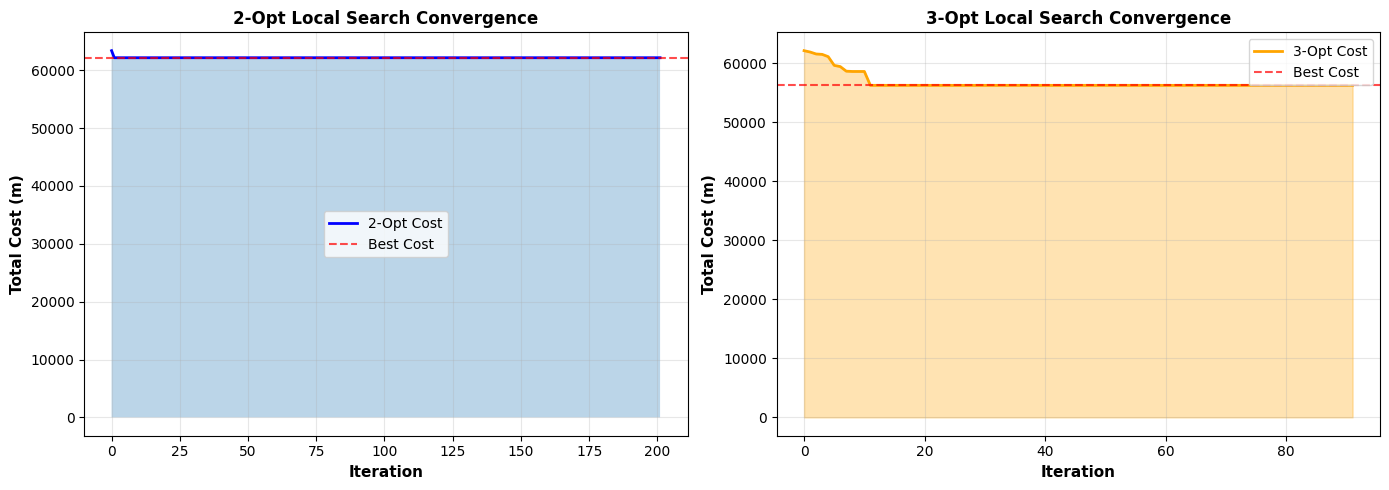

In [52]:
# Visualize 2-Opt & 3-Opt Improvement Curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2-Opt convergence
ax1 = axes[0]
ax1.plot(two_opt_result['history'], 'b-', linewidth=2, label='2-Opt Cost')
ax1.axhline(y=two_opt_best_cost, color='r', linestyle='--', alpha=0.7, label='Best Cost')
ax1.fill_between(range(len(two_opt_result['history'])), two_opt_result['history'], alpha=0.3)
ax1.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Cost (m)', fontsize=11, fontweight='bold')
ax1.set_title('2-Opt Local Search Convergence', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# 3-Opt convergence
ax2 = axes[1]
ax2.plot(three_opt_result['history'], 'orange', linewidth=2, label='3-Opt Cost')
ax2.axhline(y=three_opt_best_cost, color='r', linestyle='--', alpha=0.7, label='Best Cost')
ax2.fill_between(range(len(three_opt_result['history'])), three_opt_result['history'], alpha=0.3, color='orange')
ax2.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax2.set_ylabel('Total Cost (m)', fontsize=11, fontweight='bold')
ax2.set_title('3-Opt Local Search Convergence', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("local_search_convergence.png", dpi=300, bbox_inches='tight')
print("✓ Visualisasi tersimpan: 'local_search_convergence.png'")
plt.show()

In [53]:
# Update Comparison with Local Search Methods
print("=" * 80)
print("📊 COMPARISON: ALL 6 ALGORITHMS (4 Metaheuristics + 2 Local Search)")
print("=" * 80)

# Update algorithm list
algo_names_extended = ['NN', 'PSO', 'SA', 'ACO', '2-Opt', '3-Opt']
costs_total_extended = [
    nn_best_cost,
    pso_best_cost,
    sa_best_cost,
    aco_best_cost,
    two_opt_best_cost,
    three_opt_best_cost
]
costs_aspal_extended = [
    nn_pure_distance,
    pso_pure_distance,
    sa_pure_distance,
    aco_pure_distance,
    two_opt_pure_distance,
    three_opt_pure_distance
]
penalties_extended = [
    nn_best_cost - nn_pure_distance,
    pso_best_cost - pso_pure_distance,
    sa_best_cost - sa_pure_distance,
    aco_best_cost - aco_pure_distance,
    two_opt_best_cost - two_opt_pure_distance,
    three_opt_best_cost - three_opt_pure_distance
]

# Create ranking
ranked_extended = sorted(zip(algo_names_extended, costs_total_extended), key=lambda x: x[1])

print("\n🏆 RANKING (dari terbaik ke terburuk):")
print("-" * 80)
for rank, (algo, cost) in enumerate(ranked_extended, 1):
    purity = (costs_aspal_extended[algo_names_extended.index(algo)] / cost) * 100
    improvement_vs_nn = ((nn_best_cost - cost) / nn_best_cost) * 100
    print(f"{rank}. {algo:8} | {cost/1000:7.2f} km | Aspal: {purity:5.1f}% | vs NN: {improvement_vs_nn:+6.2f}%")

print("-" * 80)
print(f"Best:  {ranked_extended[0][0]} ({ranked_extended[0][1]/1000:.2f} km)")
print(f"Worst: {ranked_extended[-1][0]} ({ranked_extended[-1][1]/1000:.2f} km)")
print(f"Range: {(ranked_extended[-1][1] - ranked_extended[0][1])/1000:.2f} km")

# Create detailed comparison table
import pandas as pd

comparison_data_extended = {
    'Algoritma': algo_names_extended,
    'Total Cost (km)': [c/1000 for c in costs_total_extended],
    'Jarak Aspal (km)': [c/1000 for c in costs_aspal_extended],
    'Penalti Elevasi (km)': [p/1000 for p in penalties_extended],
    'Tipe': ['Metaheuristic (Greedy)', 'Metaheuristic (Swarm)', 'Metaheuristic (Thermal)', 
             'Metaheuristic (Swarm)', 'Local Search (2-edge)', 'Local Search (3-edge)'],
    'Waktu': ['Instant', '~3s', '~5s', '~5s', '~2s', '~8s']
}

df_extended = pd.DataFrame(comparison_data_extended)
df_extended = df_extended.sort_values('Total Cost (km)')
print("\n" + df_extended.to_string(index=False))

📊 COMPARISON: ALL 6 ALGORITHMS (4 Metaheuristics + 2 Local Search)

🏆 RANKING (dari terbaik ke terburuk):
--------------------------------------------------------------------------------
1. ACO      |   50.10 km | Aspal:  95.9% | vs NN: +20.96%
2. 3-Opt    |   56.29 km | Aspal:  96.1% | vs NN: +11.20%
3. 2-Opt    |   62.17 km | Aspal:  96.5% | vs NN:  +1.92%
4. NN       |   63.38 km | Aspal:  96.8% | vs NN:  +0.00%
5. SA       |   63.38 km | Aspal:  96.8% | vs NN:  +0.00%
6. PSO      |   85.67 km | Aspal:  97.2% | vs NN: -35.15%
--------------------------------------------------------------------------------
Best:  ACO (50.10 km)
Worst: PSO (85.67 km)
Range: 35.57 km

Algoritma  Total Cost (km)  Jarak Aspal (km)  Penalti Elevasi (km)                    Tipe   Waktu
      ACO          50.0969           48.0469                  2.05   Metaheuristic (Swarm)     ~5s
    3-Opt          56.2861           54.0861                  2.20   Local Search (3-edge)     ~8s
    2-Opt          62.1650


✓ Visualisasi tersimpan: 'comparison_6_algorithms.png'


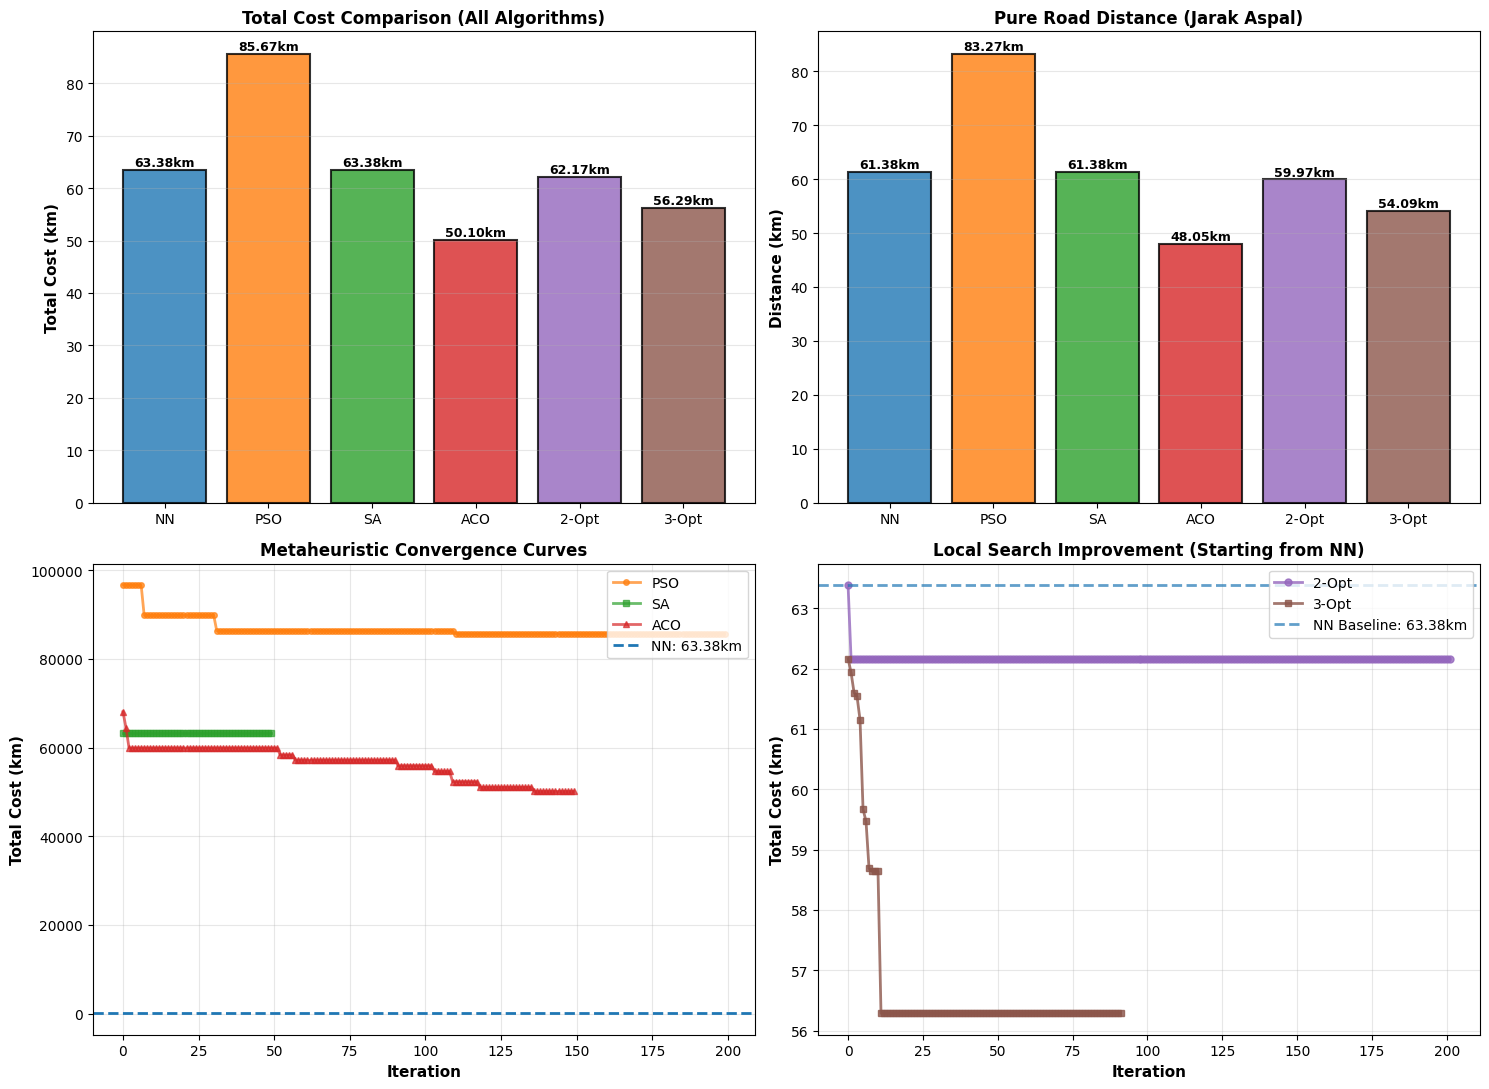


✅ Perbandingan lengkap 6 algoritma selesai!


In [54]:
# Comprehensive 6-Algorithm Comparison Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Define colors for better visualization
colors_extended = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Panel 1: Total Cost Comparison (Bar Chart)
ax1 = axes[0, 0]
x_pos = np.arange(len(algo_names_extended))
bars = ax1.bar(x_pos, [c/1000 for c in costs_total_extended], color=colors_extended, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel("Total Cost (km)", fontsize=11, fontweight='bold')
ax1.set_title("Total Cost Comparison (All Algorithms)", fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(algo_names_extended, fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, cost) in enumerate(zip(bars, costs_total_extended)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{cost/1000:.2f}km', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Pure Distance (Aspal) Comparison
ax2 = axes[0, 1]
bars = ax2.bar(x_pos, [c/1000 for c in costs_aspal_extended], color=colors_extended, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel("Distance (km)", fontsize=11, fontweight='bold')
ax2.set_title("Pure Road Distance (Jarak Aspal)", fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(algo_names_extended, fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

for i, (bar, cost) in enumerate(zip(bars, costs_aspal_extended)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.15,
            f'{cost/1000:.2f}km', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 3: Convergence Curves (Metaheuristics)
ax3 = axes[1, 0]
ax3.plot(history_pso, 'o-', linewidth=2, markersize=4, color=colors_extended[1], label='PSO', alpha=0.7)
ax3.plot(history_sa, 's-', linewidth=2, markersize=4, color=colors_extended[2], label='SA', alpha=0.7)
ax3.plot(history_aco, '^-', linewidth=2, markersize=4, color=colors_extended[3], label='ACO', alpha=0.7)
ax3.axhline(y=nn_best_cost/1000, color=colors_extended[0], linestyle='--', linewidth=2, label=f'NN: {nn_best_cost/1000:.2f}km')
ax3.set_xlabel("Iteration", fontsize=11, fontweight='bold')
ax3.set_ylabel("Total Cost (km)", fontsize=11, fontweight='bold')
ax3.set_title("Metaheuristic Convergence Curves", fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10, loc='upper right')

# Panel 4: Local Search Improvement (2-Opt & 3-Opt)
ax4 = axes[1, 1]
# Normalize history to km
history_2opt_km = [h/1000 for h in two_opt_result['history']]
history_3opt_km = [h/1000 for h in three_opt_result['history']]

ax4.plot(history_2opt_km, 'o-', linewidth=2, markersize=5, color=colors_extended[4], label='2-Opt', alpha=0.8)
ax4.plot(history_3opt_km, 's-', linewidth=2, markersize=5, color=colors_extended[5], label='3-Opt', alpha=0.8)
ax4.axhline(y=nn_best_cost/1000, color=colors_extended[0], linestyle='--', linewidth=2, label=f'NN Baseline: {nn_best_cost/1000:.2f}km', alpha=0.7)
ax4.set_xlabel("Iteration", fontsize=11, fontweight='bold')
ax4.set_ylabel("Total Cost (km)", fontsize=11, fontweight='bold')
ax4.set_title("Local Search Improvement (Starting from NN)", fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig("comparison_6_algorithms.png", dpi=300, bbox_inches='tight')
print("\n✓ Visualisasi tersimpan: 'comparison_6_algorithms.png'")
plt.show()

print("\n✅ Perbandingan lengkap 6 algoritma selesai!")